- From noiseless to DC2 images
- Test of different architecture
- Impact of usage of PSF
- Impact of usage of fft
- First diff on Bayesian neural network

Test are done with sample up to 24.5 magnitude

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import scipy.stats as stats

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0512 18:57:18.669969 139702198884160 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


## Load data

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_24.5_v2/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

## Load transformations of ellipticities

### for inputs

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

## Load models

### Loading directories

In [4]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

#dir_model_v1 = root_dir_models+'v24/loss/'#'v12/loss/'  # all concats at each convolution block
dir_model_v2 = root_dir_models+'v_test/loss/'#'v14/loss/'  # concat only after all convolution blocks
dir_model_v3 = root_dir_models+'v15/loss/'#'v15/loss/'  # No use of PSF
#dir_model_v4 = root_dir_models+'v25/loss/'#'v16/loss/'  # concat only after all convolution blocks add one intermediate Dense layer after concat
dir_model_v5 = root_dir_models+'v17/loss/'#'v17/loss/'  # BNN with concat after all convolution blocks

### Set models parameters

In [5]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

### Define and load models

In [6]:
model_concat_one = model.create_model_wo_ls_peak_pooling_concat_one(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_no_psf = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_bnn = model.create_model_prob_flipout_peak(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0512 18:57:21.294852 139702198884160 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0512 18:57:21.757624 139702198884160 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.
W0512 18:57:22.554667 139702198884160 deprecation.py:323] From ../../scripts/tools_for_VAE/tool

[8192, 256]
Tensor("dense_flipout/Size:0", shape=(), dtype=int32)
[256, 5]
Tensor("dense_flipout_1/Size:0", shape=(), dtype=int32)


In [7]:
#latest = tf.train.latest_checkpoint(dir_model_v1)
#model_concat_all.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v2)
model_concat_one.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v3)
model_no_psf.load_weights(latest)
#latest = tf.train.latest_checkpoint(dir_model_v4)
#model_concat_one_dense.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v5)
model_bnn.load_weights(latest)

## Training magnitude cut at 24.5 in $r$-band

### Noiseless images

### Load data 

In [8]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])


ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, shear_1, shear_2, convergence))

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


## Test of models

In [10]:
nb_of_points = 1000

In [11]:
output_v1 = model_no_psf([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

Text(0.5, 1.0, '$e2$')

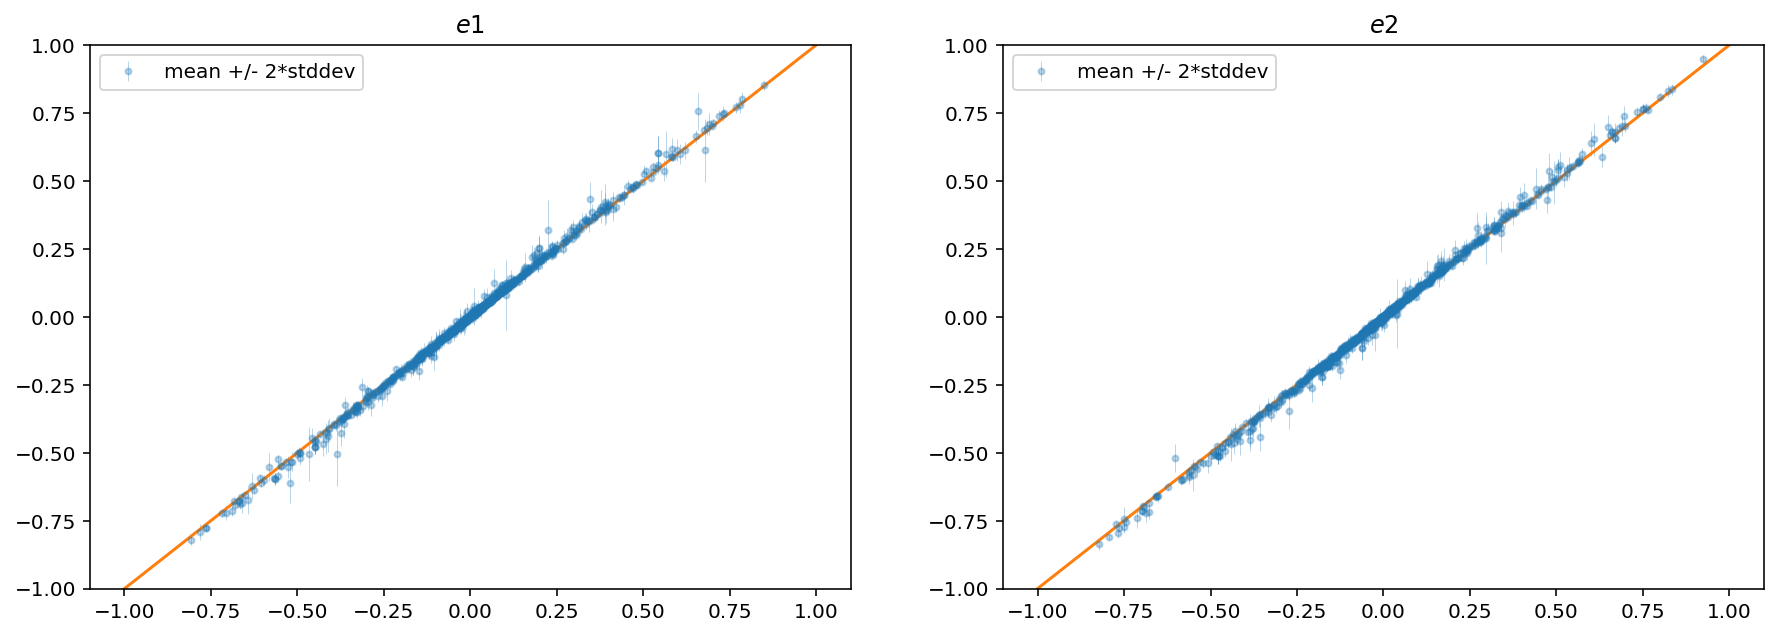

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1[:nb_of_points], e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(e2[:nb_of_points], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

In [13]:
#np.save('data/net_bnn_noiseless.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
#np.save('data/net_one_concat_dense.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
#np.save('data/net_all_concat.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
#np.save('data/net_once_concat_noiseless.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
np.save('data/net_no_psf_noiseless.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))

### Load saved results

In [16]:
e1_out_mean_once_concat, e2_out_mean_once_concat, e1_out_std_once_concat, e2_out_std_once_concat = np.load('data/net_once_concat_noiseless.npy')
#e1_out_mean_all_concat, e2_out_mean_all_concat, e1_out_std_all_concat, e2_out_std_all_concat = np.load('data/net_all_concat.npy')
e1_out_mean_bnn, e2_out_mean_bnn, e1_out_std_bnn, e2_out_std_bnn = np.load('data/net_bnn_noiseless.npy')
e1_out_mean_no_psf, e2_out_mean_no_psf, e1_out_std_no_psf, e2_out_std_no_psf = np.load('data/net_no_psf_noiseless.npy')
#e1_out_mean_one_concat_dense, e2_out_mean_one_concat_dense, e1_out_std_one_concat_dense, e2_out_std_one_concat_dense = np.load('data/net_one_concat_dense.npy')

In [17]:
nb_of_points = 1000

Std as function of SNR: how does aleatoric uncertainty react to SNR ?

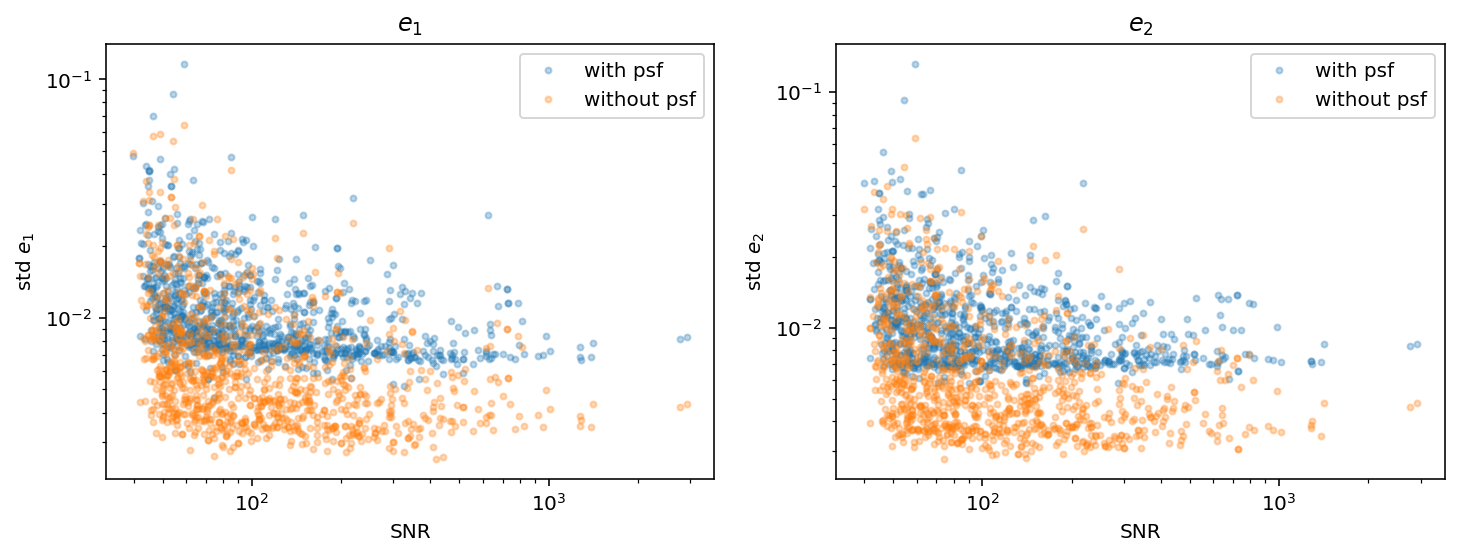

In [12]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(data['snr_r'][:nb_of_points], e1_out_std_once_concat, '.', alpha = 0.3, label = 'with psf')
axes[0].plot(data['snr_r'][:nb_of_points], e1_out_std_no_psf, '.', alpha = 0.3, label = 'without psf')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('SNR')
axes[0].set_ylabel('std $e_1$')
axes[0].set_title('$e_1$')
axes[0].legend()

axes[1].plot(data['snr_r'][:nb_of_points], e2_out_std_once_concat, '.', alpha = 0.3, label = 'with psf')
axes[1].plot(data['snr_r'][:nb_of_points], e2_out_std_no_psf, '.', alpha = 0.3, label = 'without psf')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('SNR')
axes[1].set_ylabel('std $e_2$')
axes[1].set_title('$e_2$')
axes[1].legend()

Models comparison

In [20]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_bnn,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_bnn,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_bnn,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_bnn,e2_out_std_no_psf]

labels=['det one concat', 'BNN', 'det no psf']

In [45]:
def compar_models(mean_results_e1, mean_results_e2,e1_out_std,e2_out_std, param, xlim, labels, log = True):
    
    fig, axes = plt.subplots(3,3, figsize = (24,12))

    for i, res in enumerate (mean_results_e1):
        if log:
            bins=np.logspace(np.log10(xlim[0]),np.log10(xlim[1]), 11)

            axes[0,0].set_xscale('log')
            axes[0,1].set_xscale('log')
            axes[0,2].set_xscale('log')
            axes[1,1].set_xscale('log')
            axes[1,0].set_xscale('log')
            axes[1,2].set_xscale('log')
            axes[2,1].set_xscale('log')
            axes[2,0].set_xscale('log')
            axes[2,2].set_xscale('log')
        else:
            bins=np.linspace(xlim[0],xlim[1],11)

        axes[0,0].set_xlim(xlim)
        axes[0,1].set_xlim(xlim)
        axes[0,2].set_xlim(xlim)
        axes[1,1].set_xlim(xlim)
        axes[1,0].set_xlim(xlim)
        axes[1,2].set_xlim(xlim) 
        axes[2,1].set_xlim(xlim)
        axes[2,0].set_xlim(xlim)
        axes[2,2].set_xlim(xlim) 

        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e1[i]+e1[:nb_of_points])/e1_out_std[i], statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e1[i]+e1[:nb_of_points])/e1_out_std[i], statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,0].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,0].legend()
        axes[0,0].set_title('mean $e_1$')
        
        axes[1,0].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,0].set_title('std of means $e_1$')
        
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], std_results_e1[i], statistic='mean', bins=bins)
        axes[2,0].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,0].set_title('mean uncertainty $e_1$')
        
        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e2[i]+e2[:nb_of_points])/e2_out_std[i], statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e2[i]+e2[:nb_of_points])/e2_out_std[i], statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,1].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,1].legend()
        axes[0,1].set_title('mean $e_2$')
        axes[1,1].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,1].set_title('std of means $e_2$')
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], std_results_e2[i], statistic='mean', bins=bins)
        axes[2,1].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,1].set_title('mean uncertainty $e_2$')

        e = np.sqrt(e1[:nb_of_points]**2+e2[:nb_of_points]**2)
        e_out = np.sqrt(mean_results_e1[i]**2+mean_results_e2[i]**2)
        std_sqrt = np.sqrt(std_results_e1[i]**2+std_results_e2[i]**2)
        e_std = np.sqrt(e1_out_std[i]**2+e2_out_std[i]**2)

        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points],(e_out-e)/e_std, statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (e_out-e)/e_std, statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,2].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,2].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,2].legend()
        axes[0,2].set_title('mean e')
        axes[1,2].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,2].set_title('std of means e')
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], e_std, statistic='mean', bins=bins)
        axes[2,2].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,2].set_title('mean uncertainty e')

In [46]:
e = np.sqrt(e1**2+e2**2)
data['e']=e

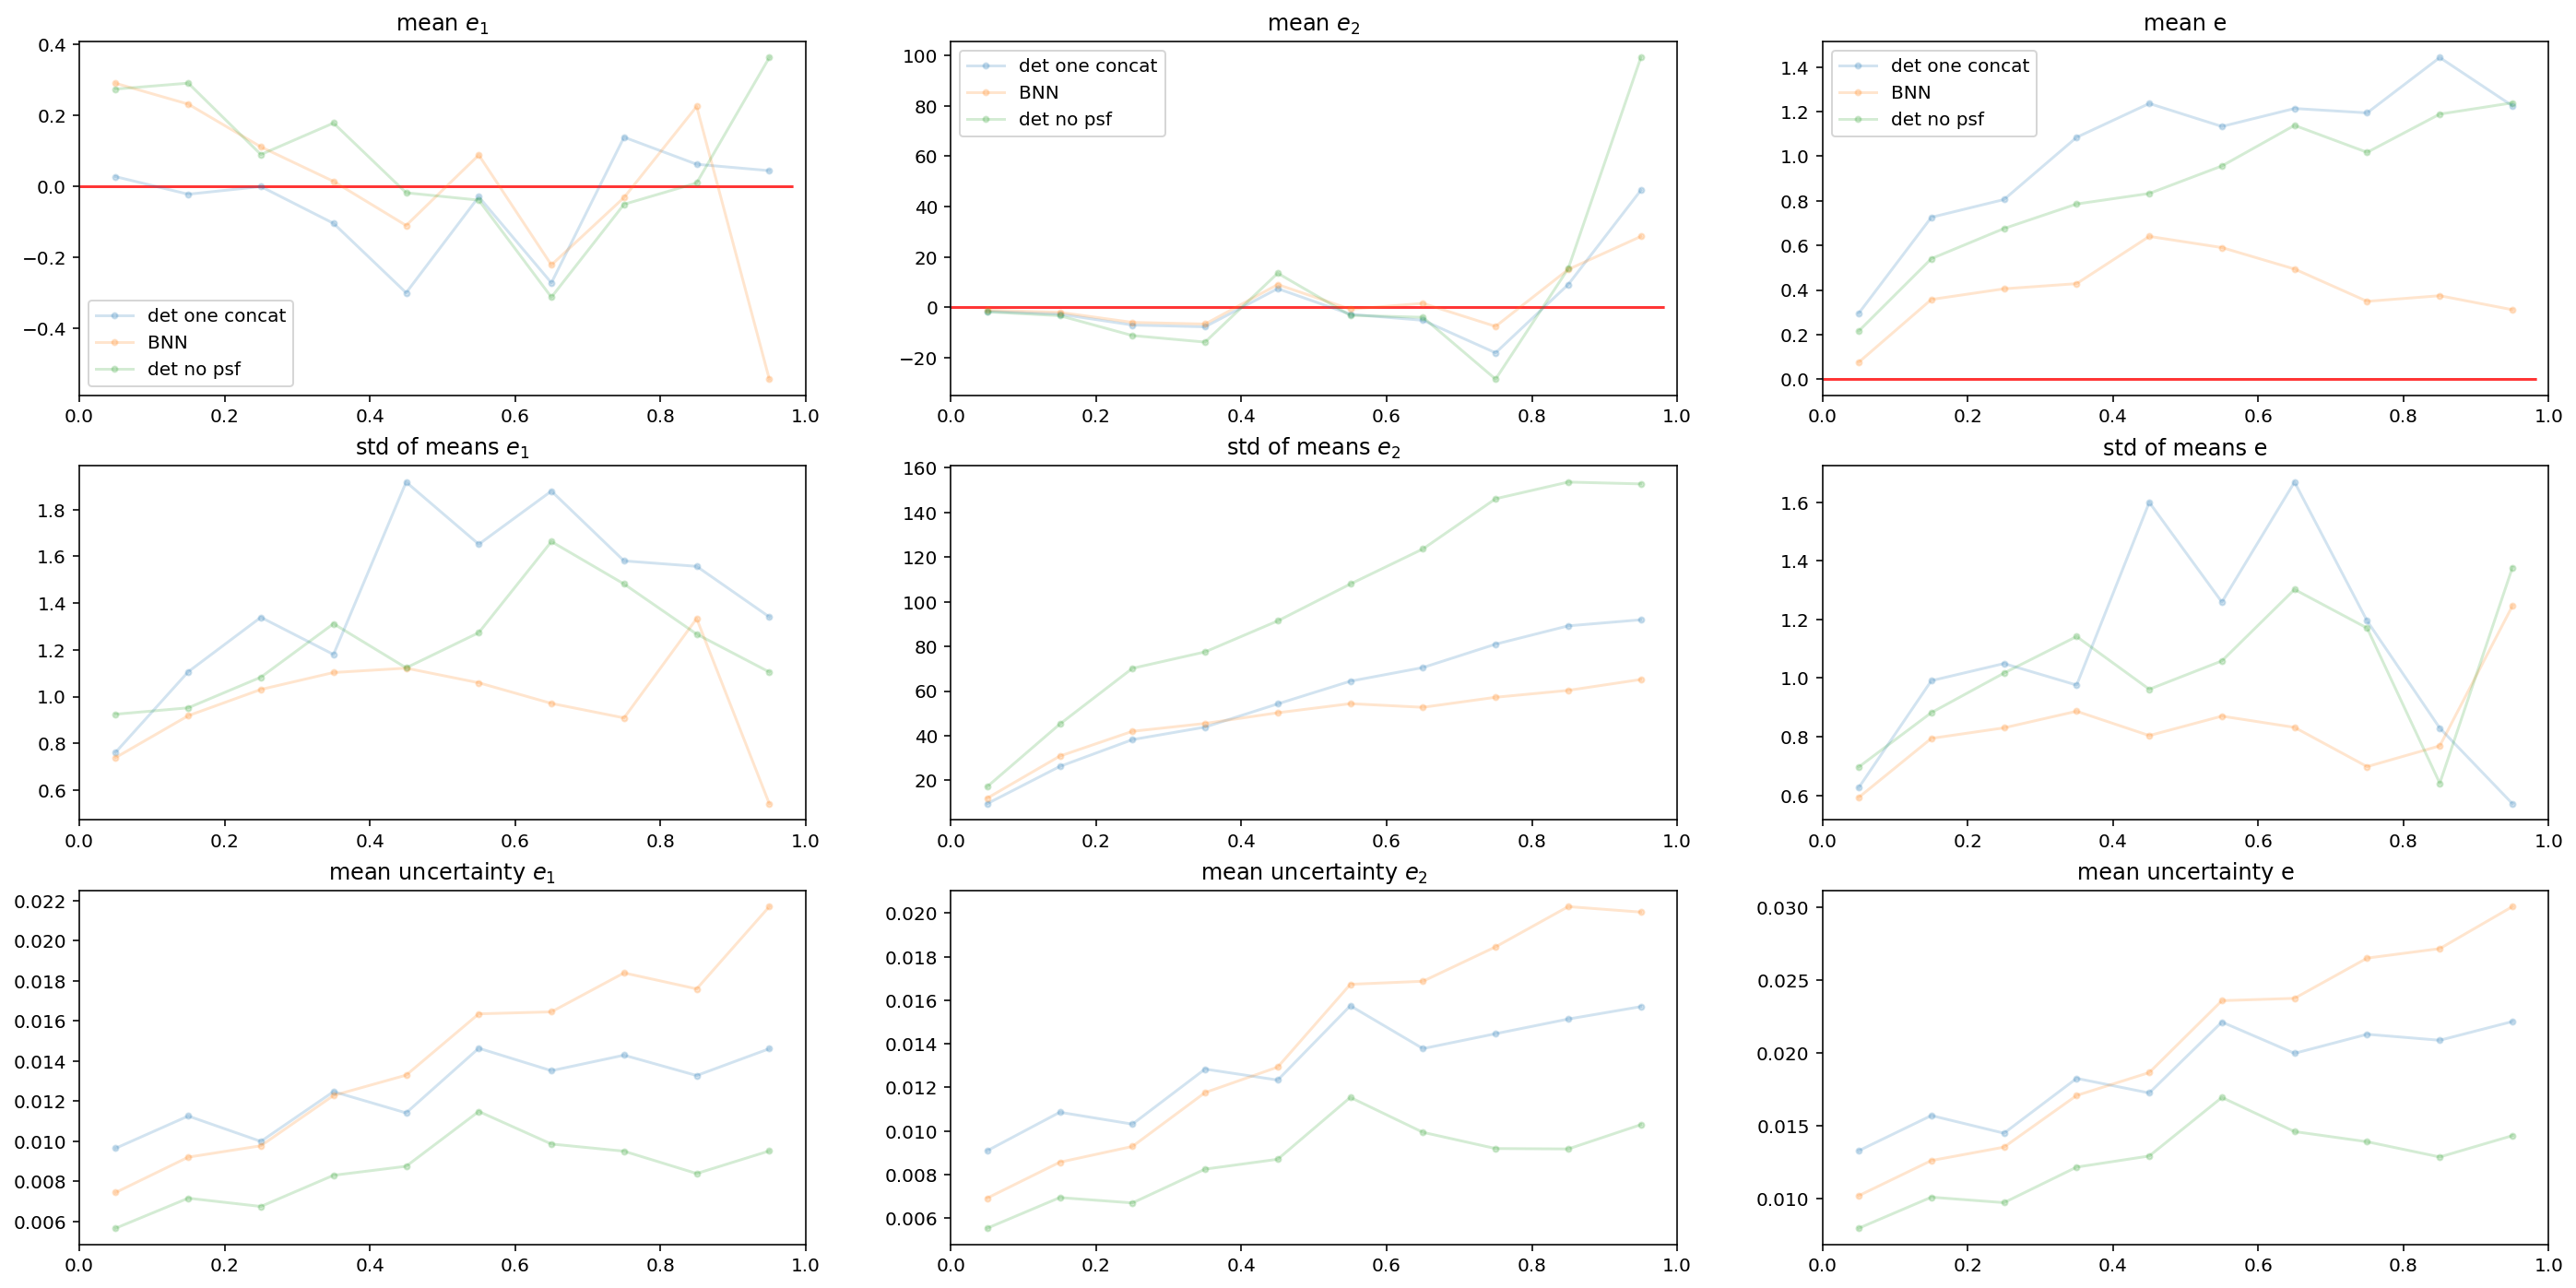

In [47]:
compar_models(mean_results_e1, mean_results_e2,std_results_e1,std_results_e2, 'e', xlim = (0,1), labels=labels, log = False)

## Test on images : noiseless images

In [18]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_bnn,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_bnn,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_bnn,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_bnn,e2_out_std_no_psf]

labels=['det one concat', 'BNN', 'det no psf']

In [10]:
def gaussian(mean,std):
    return (1/(std*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean)/(2*std**2)))

In [20]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')

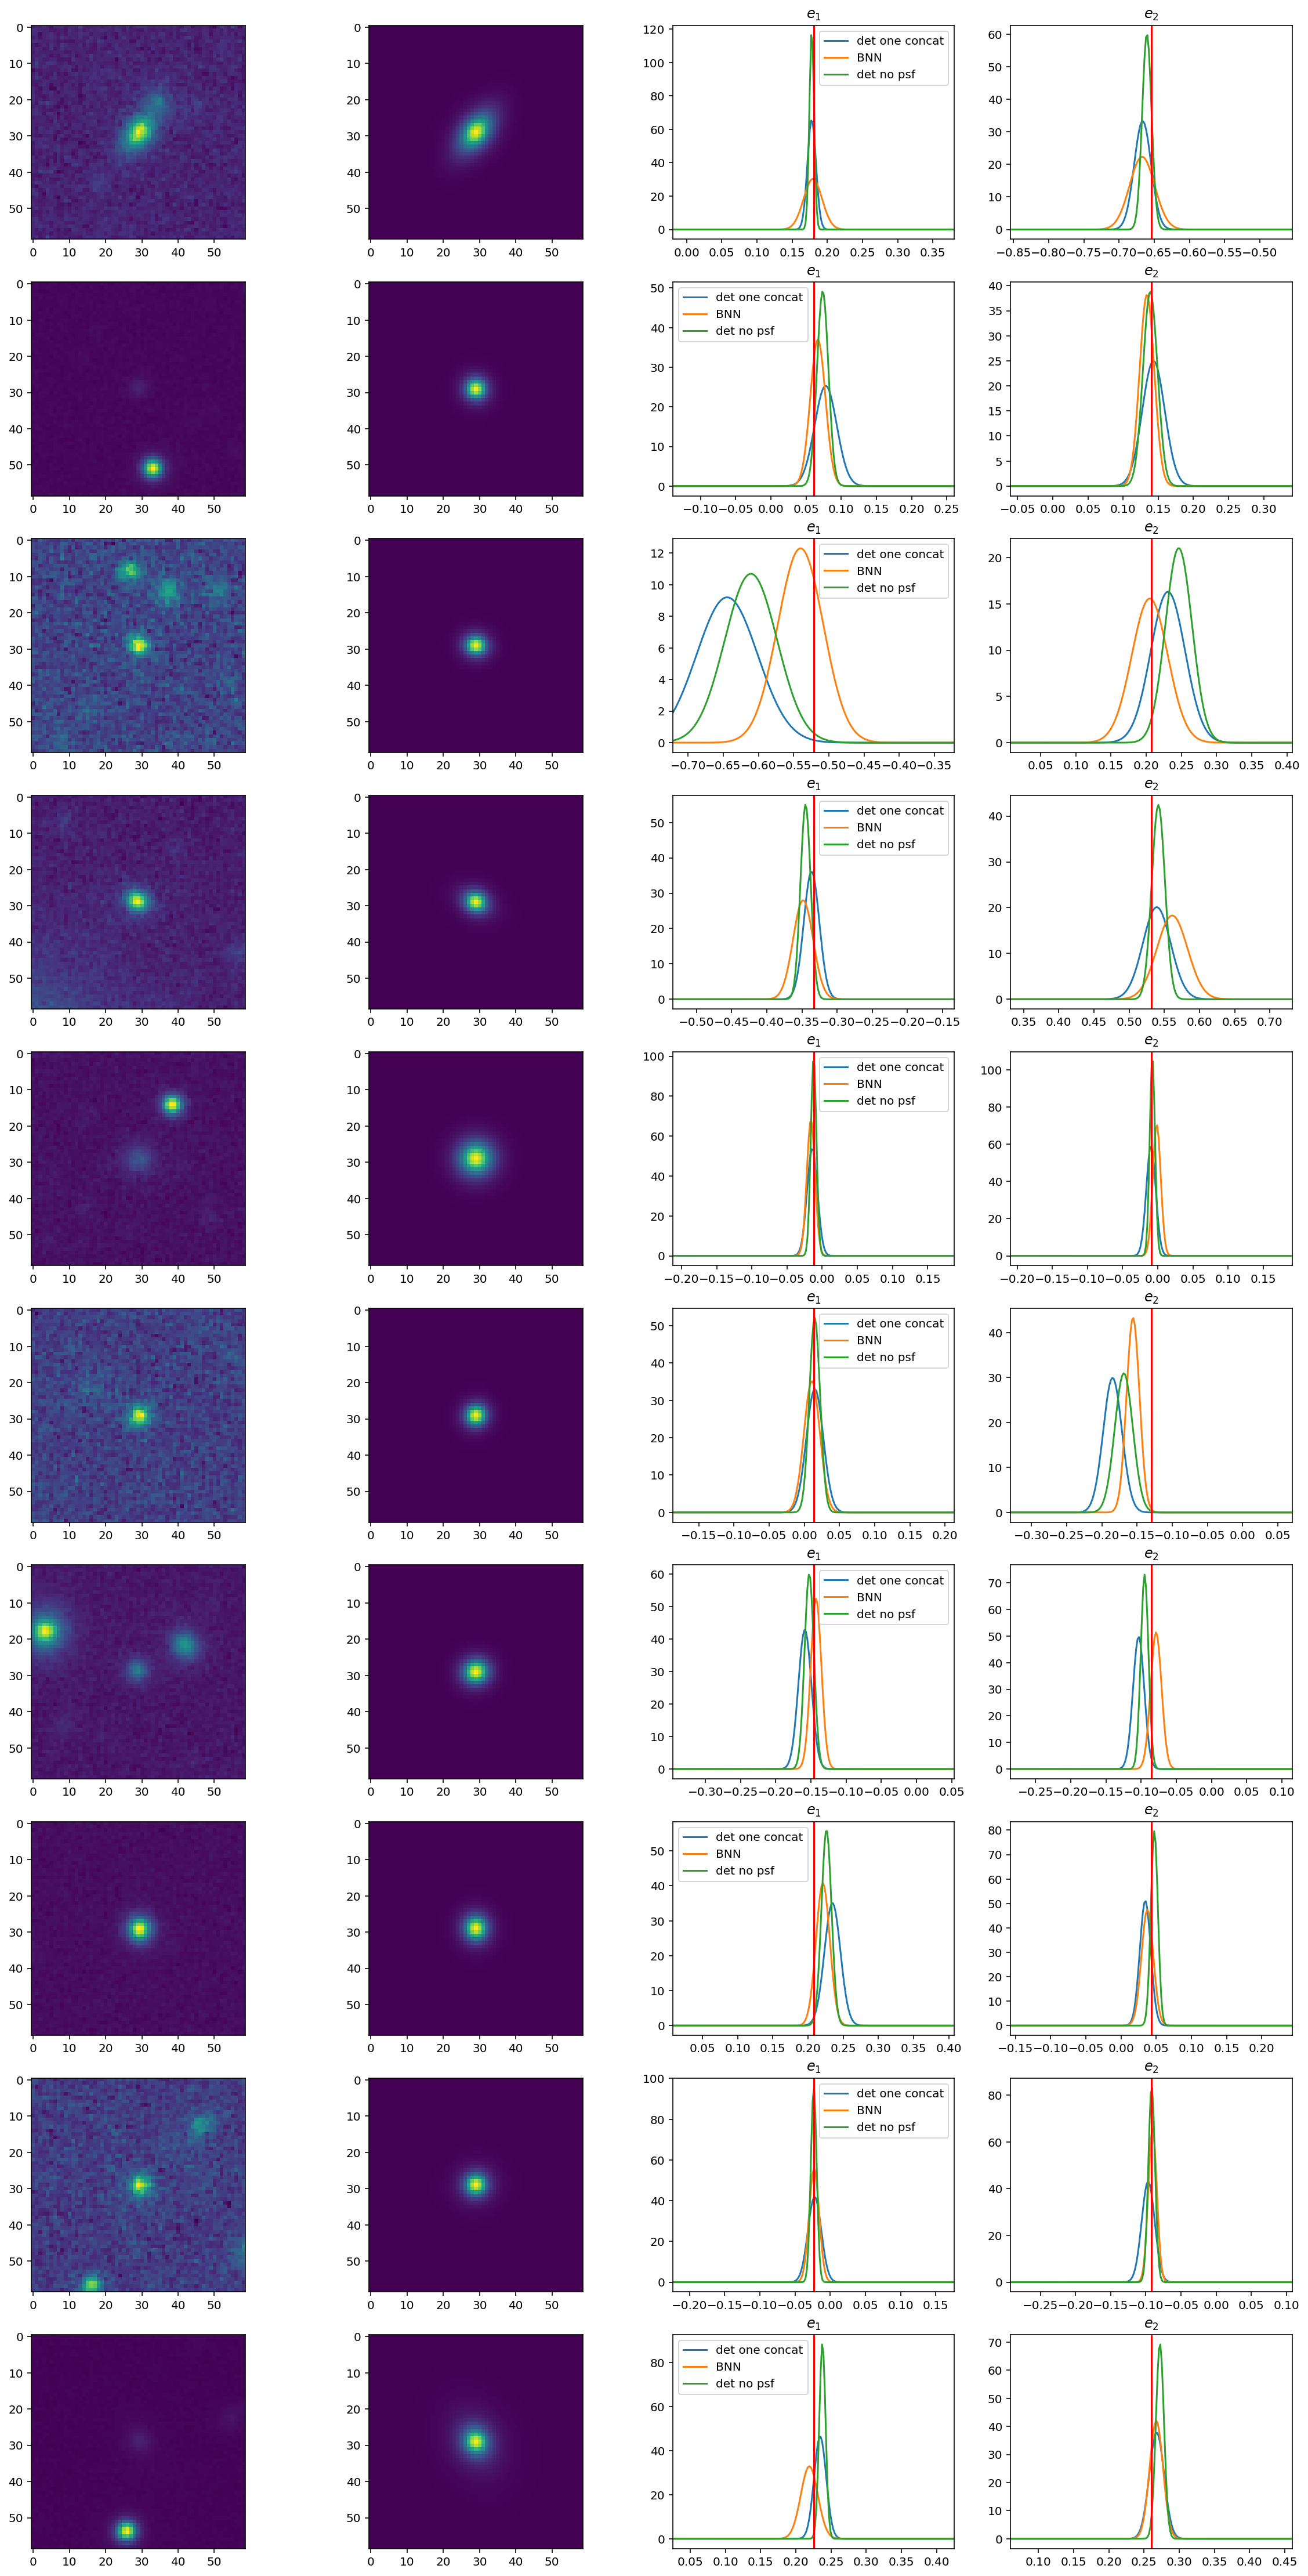

In [77]:
fig, axes = plt.subplots(10,4, figsize = (20, 40))

x = np.linspace(-1,1, 1000)
for i in range (10):
    axes[i,0].imshow(images_noisy[i,:,:,2])
    axes[i,1].imshow(images[i,:,:,2])
    for k in range(3):
        _ = axes[i,2].plot(x, gaussian(mean_results_e1[k][i], std_results_e1[k][i]), label = labels[k])
        _ = axes[i,3].plot(x, gaussian(mean_results_e2[k][i], std_results_e2[k][i]), label = labels[k])
    axes[i,2].axvline(-e1[i], color = 'r')
    axes[i,3].axvline(e2[i], color = 'r')
    axes[i,2].set_xlim(-e1[i]-0.2,-e1[i]+0.2)
    axes[i,3].set_xlim(e2[i]-0.2,e2[i]+0.2)
    axes[i,2].set_title('$e_1$')
    axes[i,3].set_title('$e_2$')
    axes[i,2].legend()

#### For BNN: Evaluate aleatoric and epistemic uncertainty

In [19]:
N = 10
n_images = 500

image_array = np.zeros((n_images*N,59,59,6))
psf_array = np.zeros((n_images*N,59,59,6))

for z in range (N):
    image_array[z*n_images:(z+1)*n_images] =  images[:n_images]
    psf_array[z*n_images:(z+1)*n_images] =  psf[:n_images]
    

output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])

In [20]:
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]


e1_out_mean_bnn = np.zeros((n_images,N))
e2_out_mean_bnn = np.zeros((n_images,N))
e1_out_std_bnn = np.zeros((n_images,N))
e2_out_std_bnn = np.zeros((n_images,N))

for i in range (N):
    for k in range (n_images):
        e1_out_mean_bnn[k,i] = e1_mean[k+i*n_images]
        e2_out_mean_bnn[k,i] = e2_mean[k+i*n_images]

        e1_out_std_bnn[k,i] = e1_std[k+i*n_images]
        e2_out_std_bnn[k,i] = e2_std[k+i*n_images]

In [23]:
std_e1_epistemic_noiseless=np.zeros((n_images,))
std_e2_epistemic_noiseless=np.zeros((n_images,))
std_e1_aleatoric_noiseless=np.zeros((n_images,))
std_e2_aleatoric_noiseless=np.zeros((n_images,))
std_e1_predictive_noiseless=np.zeros((n_images,))
std_e2_predictive_noiseless=np.zeros((n_images,))

e1_out_mean = np.zeros((n_images,))
e2_out_mean = np.zeros((n_images,))
for i in range(n_images):
    e1_out_mean[i] = np.mean(e1_out_mean_bnn[i])
    e2_out_mean[i] = np.mean(e2_out_mean_bnn[i])
    std_e1_epistemic_noiseless[i] = np.std(e1_out_std_bnn[i])
    std_e1_aleatoric_noiseless[i] = np.mean(e1_out_std_bnn[i])
    std_e2_epistemic_noiseless[i] = np.std(e2_out_std_bnn[i])
    std_e2_aleatoric_noiseless[i] = np.mean(e2_out_std_bnn[i])
    std_e1_predictive_noiseless[i] = std_e1_epistemic_noiseless[i]+std_e1_aleatoric_noiseless[i]
    std_e2_predictive_noiseless[i] = std_e2_epistemic_noiseless[i]+std_e2_aleatoric_noiseless[i]

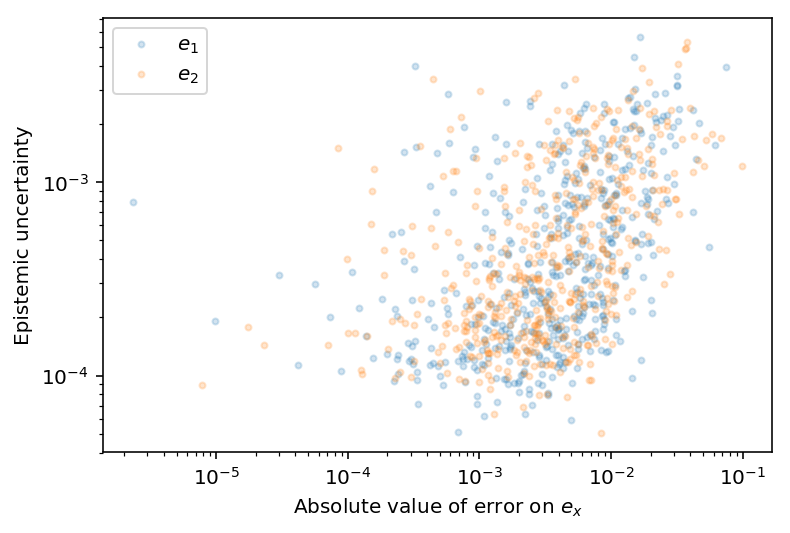

In [24]:
fig, ax = plt.subplots(1, figsize = (6,4))
ax.plot(np.abs(e1_out_mean+e1[:n_images]), std_e1_epistemic_noiseless, '.', alpha = 0.2, label = '$e_1$')
ax.plot(np.abs(e2_out_mean-e2[:n_images]), std_e2_epistemic_noiseless, '.', alpha = 0.2, label = '$e_2$')

ax.set_xlabel('Absolute value of error on $e_x$')
ax.set_ylabel('Epistemic uncertainty')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')

In [18]:
np.array(e1_out_mean).shape

(100,)

In [25]:
d = pd.DataFrame()
d['eX_err'] = np.concatenate([np.abs(e1_out_mean+e1[:n_images]),np.abs(e2_out_mean+e1[:n_images])])
d['epistemic_eX'] = np.concatenate([std_e1_epistemic_noiseless,std_e2_epistemic_noiseless])
d['aleatoric_eX'] = np.concatenate([std_e1_aleatoric_noiseless,std_e2_aleatoric_noiseless])
d['predictive_eX'] = np.concatenate([std_e1_predictive_noiseless,std_e2_predictive_noiseless])
d['exp'] = [1]*n_images + [2]*n_images

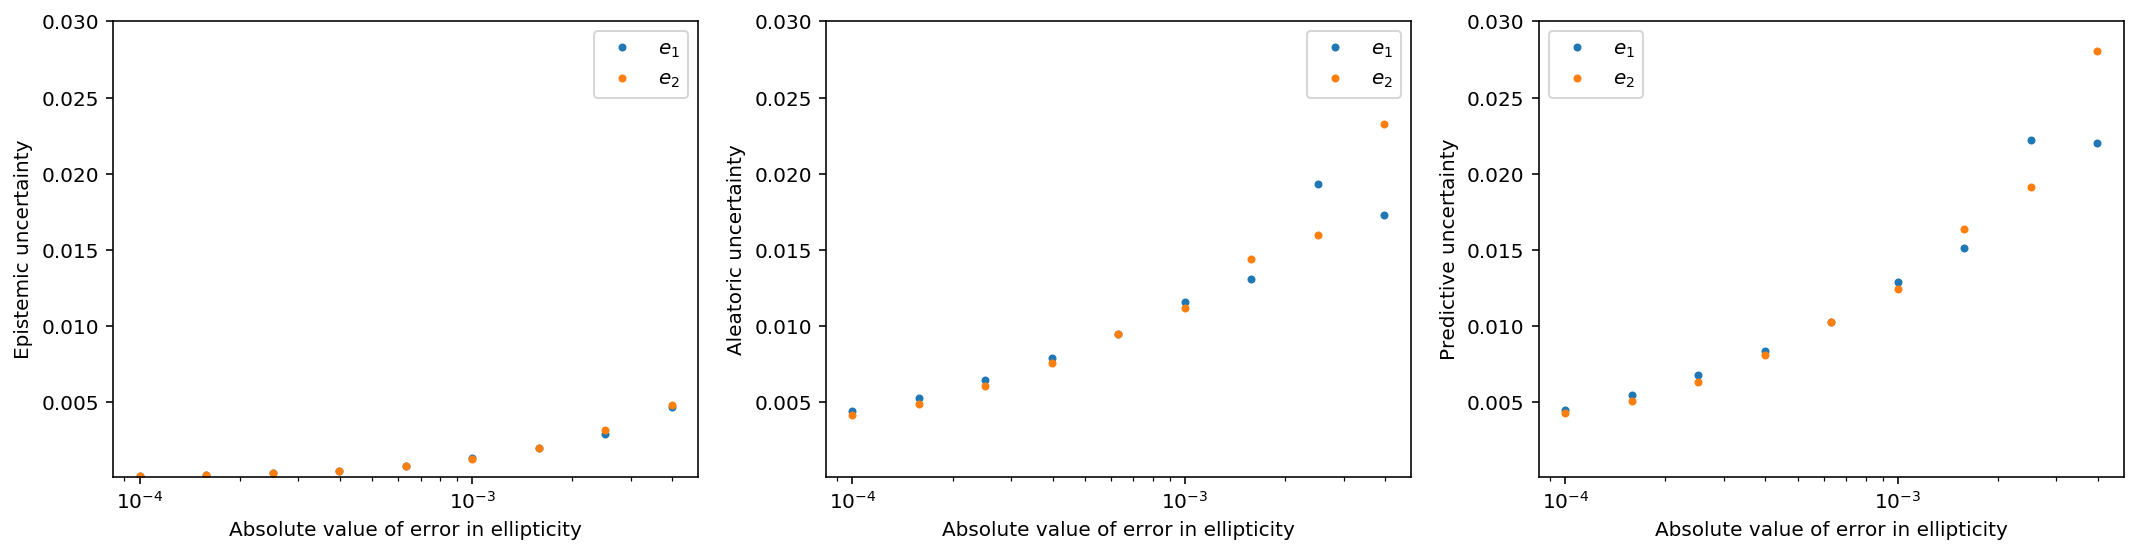

In [33]:
nbins = 10
x_bins = np.geomspace(10**(-4), 0.01, nbins+1)

idx = np.digitize(d['epistemic_eX'], x_bins)
#print(idx)
fig, axes = plt.subplots(1,3, figsize=(15,4))

m_ep =  []
m_al =  []
m_pred =  []
for ik, key in enumerate((1,2)):
    for i in range(1,len(x_bins)):
        xx = d['epistemic_eX'][np.logical_and(idx==i,d['exp']==key)].values
        m_ep.append(np.mean(xx))
        xx = d['aleatoric_eX'][np.logical_and(idx==i,d['exp']==key)].values
        m_al.append(np.mean(xx))
        xx = d['predictive_eX'][np.logical_and(idx==i,d['exp']==key)].values
        m_pred.append(np.mean(xx))
        
med_array_ep = np.array(m_ep).reshape(2,int(len(m_ep)/2))
med_array_al = np.array(m_al).reshape(2,int(len(m_al)/2))
med_array_pred = np.array(m_pred).reshape(2,int(len(m_pred)/2))
labels = ['$e_1$', '$e_2$']
for ik in range(2):
    axes[0].plot(x_bins[:-1], med_array_ep[ik], '.', label = labels[ik])
    axes[1].plot(x_bins[:-1], med_array_al[ik], '.', label = labels[ik])
    axes[2].plot(x_bins[:-1], med_array_pred[ik], '.', label = labels[ik])

axes[0].set_xscale('log')
#axes[0].set_yscale('log')
axes[0].set_xlabel('Absolute value of error in ellipticity')
axes[0].set_ylabel('Epistemic uncertainty')
axes[1].set_xscale('log')
#axes[1].set_yscale('log')
axes[1].set_xlabel('Absolute value of error in ellipticity')
axes[1].set_ylabel('Aleatoric uncertainty')
axes[2].set_xscale('log')
#axes[2].set_yscale('log')
axes[2].set_xlabel('Absolute value of error in ellipticity')
axes[2].set_ylabel('Predictive uncertainty')

axes[0].set_ylim(10**(-4), 3*10**(-2))
axes[1].set_ylim(10**(-4), 3*10**(-2))
axes[2].set_ylim(10**(-4), 3*10**(-2))

axes[0].legend()
axes[1].legend()
axes[2].legend()
fig.align_ylabels(axes)    
fig.tight_layout()
fig.subplots_adjust(hspace=0)

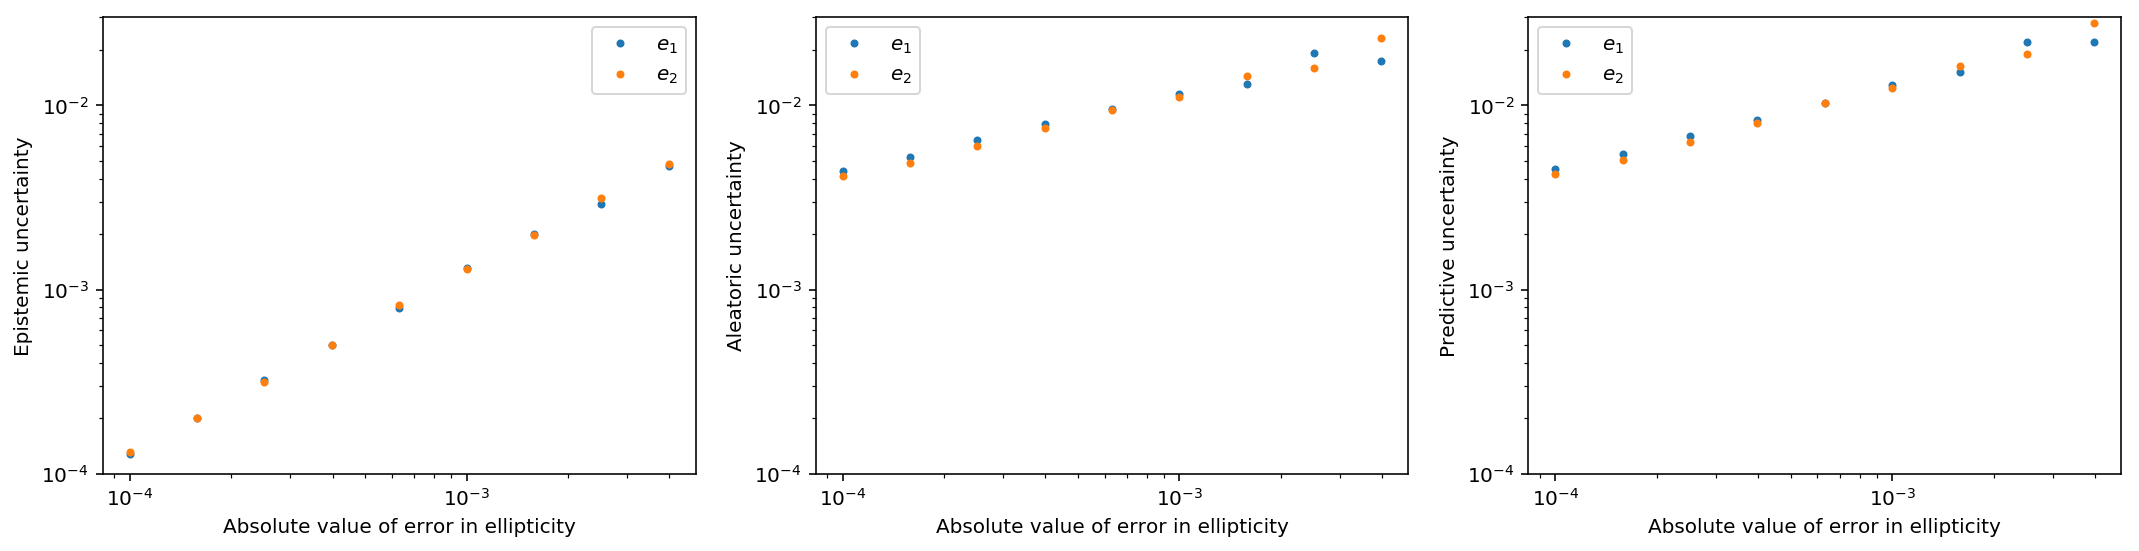

In [32]:
nbins = 10
x_bins = np.geomspace(10**(-4), 0.01, nbins+1)

idx = np.digitize(d['epistemic_eX'], x_bins)
#print(idx)
fig, axes = plt.subplots(1,3, figsize=(15,4))

m_ep =  []
m_al =  []
m_pred =  []
for ik, key in enumerate((1,2)):
    for i in range(1,len(x_bins)):
        xx = d['epistemic_eX'][np.logical_and(idx==i,d['exp']==key)].values
        m_ep.append(np.mean(xx))
        xx = d['aleatoric_eX'][np.logical_and(idx==i,d['exp']==key)].values
        m_al.append(np.mean(xx))
        xx = d['predictive_eX'][np.logical_and(idx==i,d['exp']==key)].values
        m_pred.append(np.mean(xx))
        
med_array_ep = np.array(m_ep).reshape(2,int(len(m_ep)/2))
med_array_al = np.array(m_al).reshape(2,int(len(m_al)/2))
med_array_pred = np.array(m_pred).reshape(2,int(len(m_pred)/2))
labels = ['$e_1$', '$e_2$']
for ik in range(2):
    axes[0].plot(x_bins[:-1], med_array_ep[ik], '.', label = labels[ik])
    axes[1].plot(x_bins[:-1], med_array_al[ik], '.', label = labels[ik])
    axes[2].plot(x_bins[:-1], med_array_pred[ik], '.', label = labels[ik])

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Absolute value of error in ellipticity')
axes[0].set_ylabel('Epistemic uncertainty')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Absolute value of error in ellipticity')
axes[1].set_ylabel('Aleatoric uncertainty')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('Absolute value of error in ellipticity')
axes[2].set_ylabel('Predictive uncertainty')

axes[0].set_ylim(10**(-4), 3*10**(-2))
axes[1].set_ylim(10**(-4), 3*10**(-2))
axes[2].set_ylim(10**(-4), 3*10**(-2))

axes[0].legend()
axes[1].legend()
axes[2].legend()
fig.align_ylabels(axes)    
fig.tight_layout()
fig.subplots_adjust(hspace=0)

#### For BNN: Evaluate aleatoric and epistemic uncertainty for 10 specific examples

In [70]:
N = 100

image_array = np.zeros((10*N,59,59,6))
psf_array = np.zeros((10*N,59,59,6))

for z in range (N):
    image_array[z*10:(z+1)*10] =  images[:10]
    psf_array[z*10:(z+1)*10] =  psf[:10]
    

output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])

In [71]:
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]


e1_out_mean_bnn = np.zeros((10,N))
e2_out_mean_bnn = np.zeros((10,N))
e1_out_std_bnn = np.zeros((10,N))
e2_out_std_bnn = np.zeros((10,N))

for i in range (N):
    for k in range (10):
        e1_out_mean_bnn[k,i] = e1_mean[k+i*10]
        e2_out_mean_bnn[k,i] = e2_mean[k+i*10]

        e1_out_std_bnn[k,i] = e1_std[k+i*10]
        e2_out_std_bnn[k,i] = e2_std[k+i*10]

In [110]:
N = 100

image_array = np.zeros((10*N,59,59,6))
psf_array = np.zeros((10*N,59,59,6))

for z in range (N):
    image_array[z*10:(z+1)*10] =  images_noisy[:10]
    psf_array[z*10:(z+1)*10] =  psf[:10]
    

output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])

In [111]:
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]


e1_out_mean_bnn_noisy = np.zeros((10,N))
e2_out_mean_bnn_noisy = np.zeros((10,N))
e1_out_std_bnn_noisy = np.zeros((10,N))
e2_out_std_bnn_noisy = np.zeros((10,N))

for i in range (N):
    for k in range (10):
        e1_out_mean_bnn_noisy[k,i] = e1_mean[k+i*10]
        e2_out_mean_bnn_noisy[k,i] = e2_mean[k+i*10]

        e1_out_std_bnn_noisy[k,i] = e1_std[k+i*10]
        e2_out_std_bnn_noisy[k,i] = e2_std[k+i*10]

In [52]:
np.percentile(K.get_value(output_v1[1,0]),97.5)

0.1713763177394867

In [53]:
np.percentile(K.get_value(output_v1[1,0]),2.5)

0.20861881971359253

In [46]:
gal_nb = 6

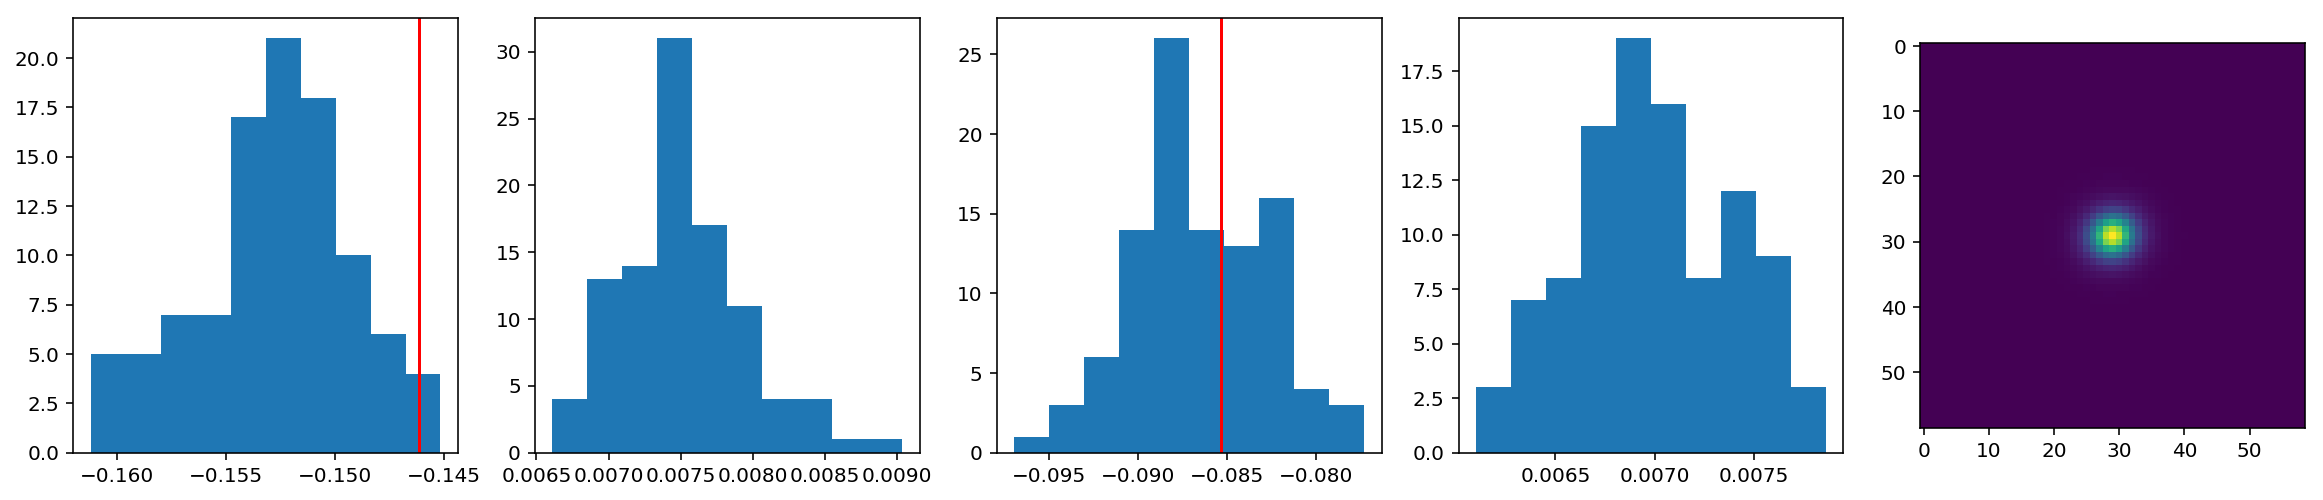

In [47]:
fig, axes = plt.subplots(1,5, figsize = (20,4))
_ = axes[0].hist(e1_out_mean_bnn[gal_nb], bins = 10)
axes[0].axvline(-e1[gal_nb], color = 'r')

_ = axes[1].hist(e1_out_std_bnn[gal_nb], bins = 10)

_ = axes[2].hist(e2_out_mean_bnn[gal_nb], bins = 10)
axes[2].axvline(e2[gal_nb], color = 'r')

_ = axes[3].hist(e2_out_std_bnn[gal_nb], bins = 10)
axes[4].imshow(images[gal_nb,:,:,2])

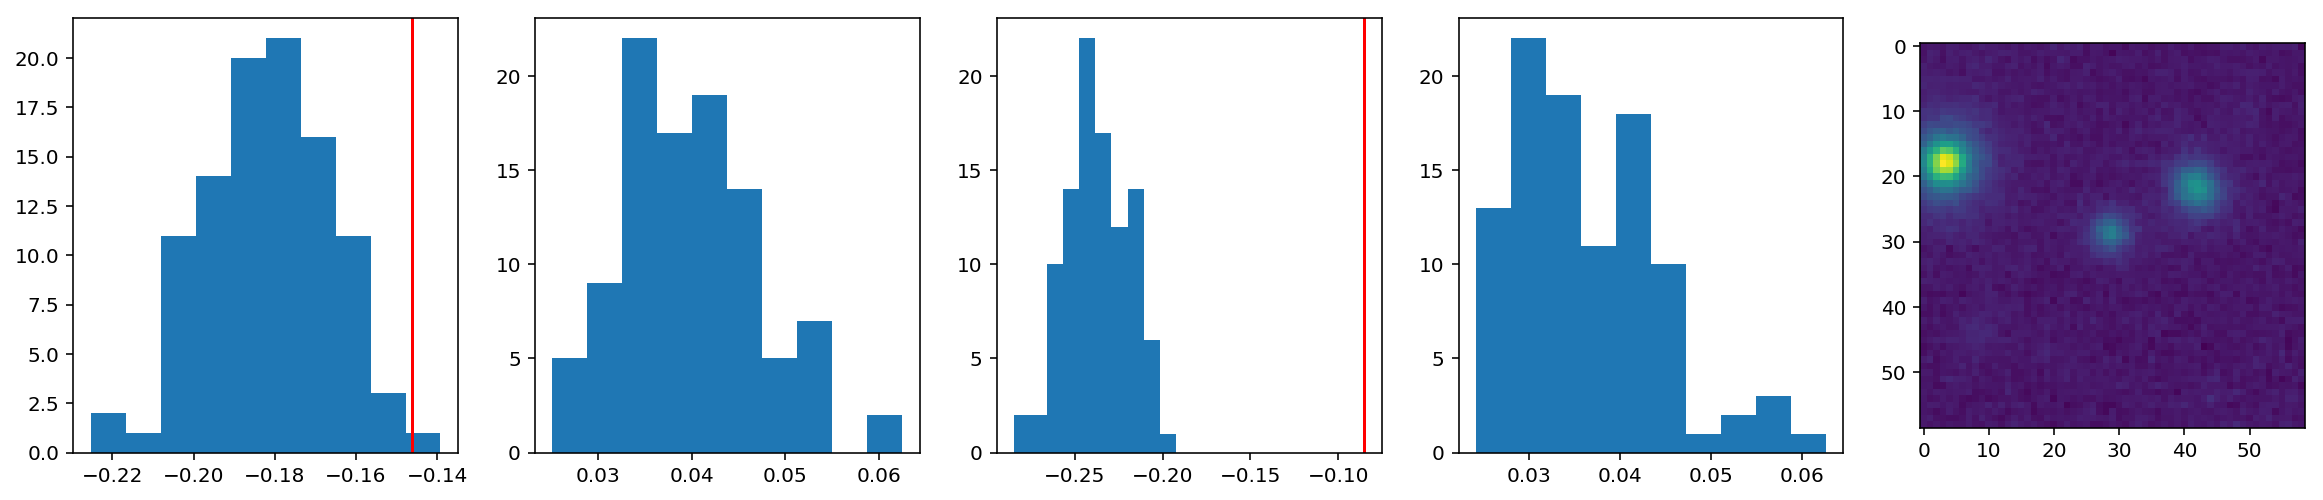

In [48]:
fig, axes = plt.subplots(1,5, figsize = (20,4))
_ = axes[0].hist(e1_out_mean_bnn_noisy[gal_nb], bins = 10)
axes[0].axvline(-e1[gal_nb], color = 'r')

_ = axes[1].hist(e1_out_std_bnn_noisy[gal_nb], bins = 10)

_ = axes[2].hist(e2_out_mean_bnn_noisy[gal_nb], bins = 10)
axes[2].axvline(e2[gal_nb], color = 'r')

_ = axes[3].hist(e2_out_std_bnn_noisy[gal_nb], bins = 10)
axes[4].imshow(images_noisy[gal_nb,:,:,2])

##### Aleatoric and epistemic uncertainties increases with noise and other galaxies on images

Text(0, 0.5, '$\\sigma^{al}_{e_2}$ - $\\sigma^{ep}_{e_2}$')

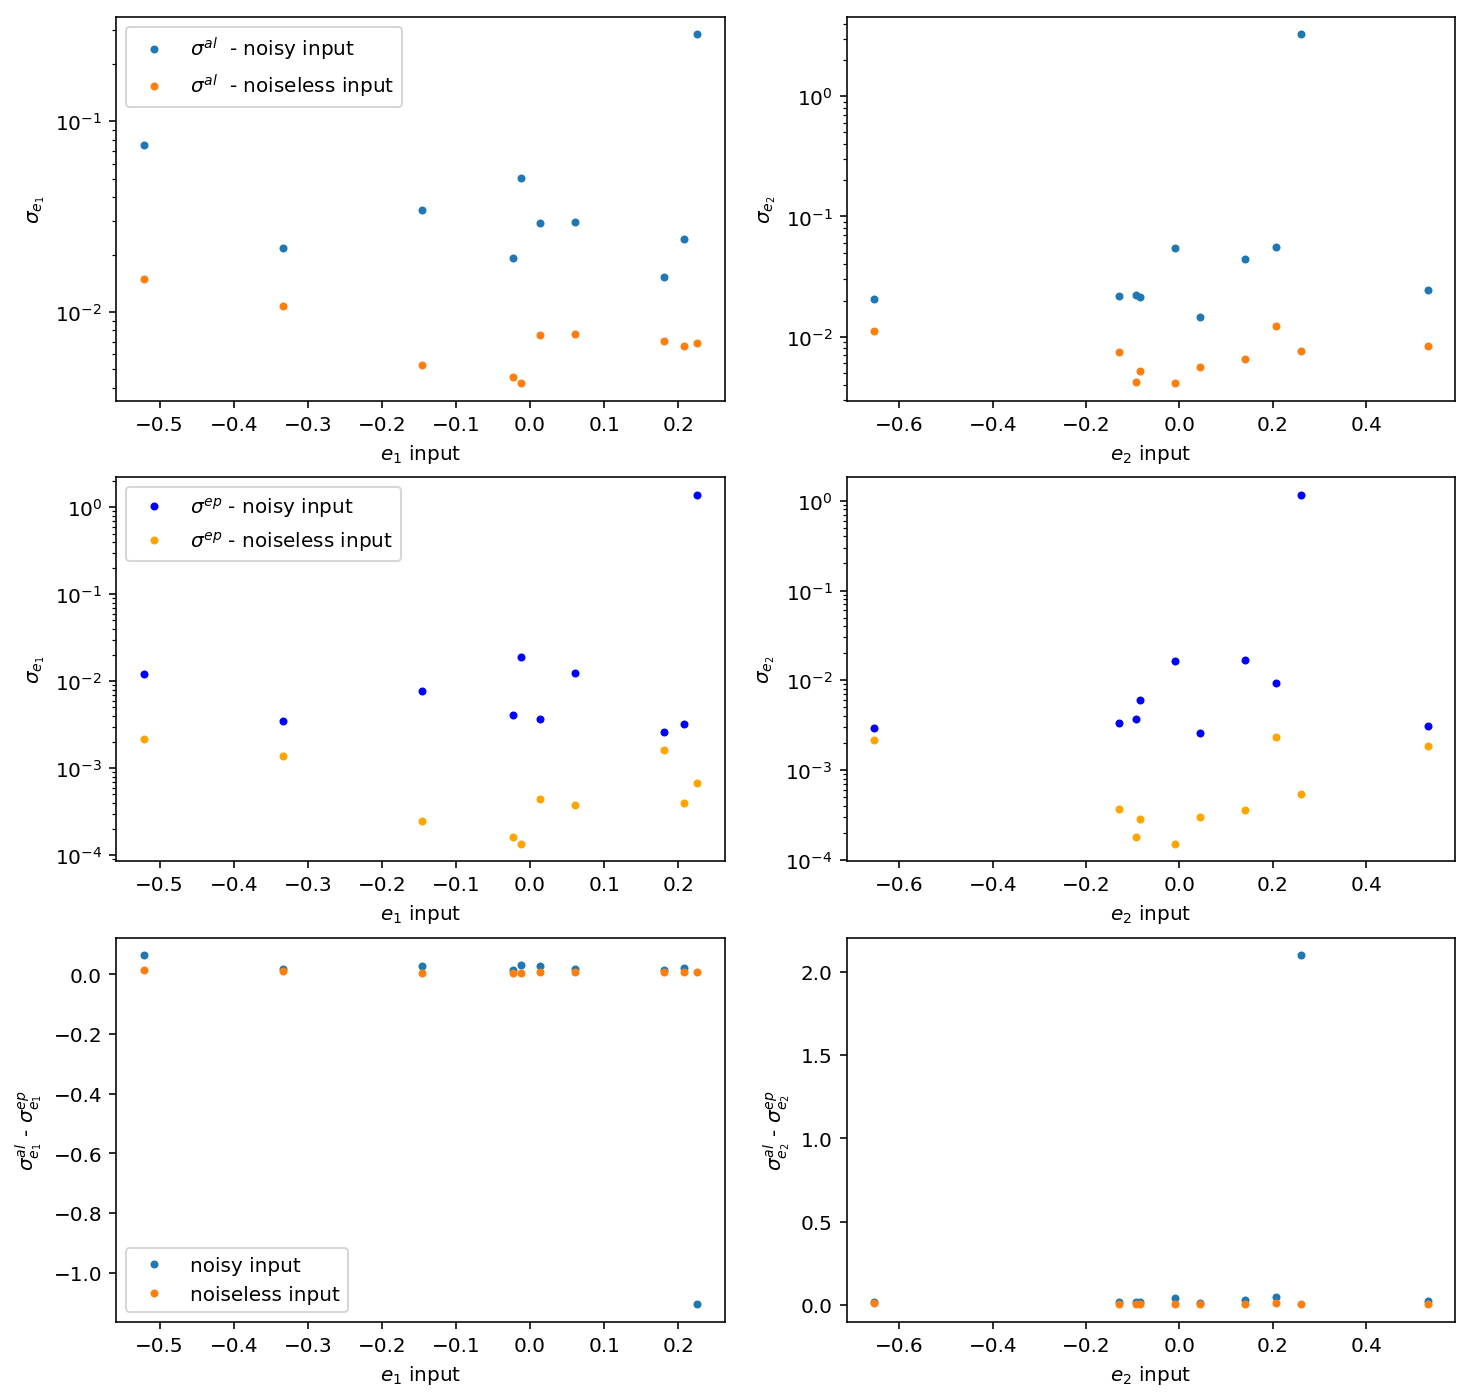

In [112]:
fig, axes = plt.subplots(3,2, figsize = (12,12))

axes[0,0].plot(-e1[:10],e1_out_std_bnn_noisy[:,0], '.', label ="$\sigma^{al}$  - noisy input")
axes[0,0].plot(-e1[:10],e1_out_std_bnn[:,0], '.', label ="$\sigma^{al}$  - noiseless input")
axes[0,0].legend()
axes[0,0].set_xlabel('$e_1$ input')
axes[0,0].set_ylabel('$\sigma_{e_1}$')

axes[0,1].plot(e2[:10],e2_out_std_bnn_noisy[:,0], '.', label ="$\sigma^{al}$  - noisy input")
axes[0,1].plot(e2[:10],e2_out_std_bnn[:,0], '.', label ="$\sigma^{al}$ - noiseless input")
#axes[1].legend()
axes[0,1].set_xlabel('$e_2$ input')
axes[0,1].set_ylabel('$\sigma_{e_2}$')

std_e1_epistemic_noisy=np.zeros((10,))
std_e2_epistemic_noisy=np.zeros((10,))
std_e1_epistemic_noiseless=np.zeros((10,))
std_e2_epistemic_noiseless=np.zeros((10,))
for i in range(10):
    std_e1_epistemic_noisy[i] = np.std(e1_out_std_bnn_noisy[i])
    std_e2_epistemic_noisy[i] = np.std(e2_out_std_bnn_noisy[i])
    std_e1_epistemic_noiseless[i] = np.std(e1_out_std_bnn[i])
    std_e2_epistemic_noiseless[i] = np.std(e2_out_std_bnn[i])
    
axes[1,0].plot(-e1[:10],std_e1_epistemic_noisy, '.', color = 'blue', label ="$\sigma^{ep}$ - noisy input")
axes[1,0].plot(-e1[:10],std_e1_epistemic_noiseless, '.', color = 'orange', label ="$\sigma^{ep}$ - noiseless input")
axes[1,0].legend()
axes[1,0].set_xlabel('$e_1$ input')
axes[1,0].set_ylabel('$\sigma_{e_1}$')

axes[1,1].plot(e2[:10],std_e2_epistemic_noisy, '.',color = 'blue', label ="$\sigma^{ep}$ - noisy input")
axes[1,1].plot(e2[:10],std_e2_epistemic_noiseless, '.',color = 'orange', label ="$\sigma^{ep}$ - noiseless input")
#axes[1].legend()
axes[1,1].set_xlabel('$e_2$ input')
axes[1,1].set_ylabel('$\sigma_{e_2}$')

axes[0,0].set_yscale('log')
axes[0,1].set_yscale('log')
axes[1,0].set_yscale('log')
axes[1,1].set_yscale('log')


axes[2,0].plot(-e1[:10], e1_out_std_bnn_noisy[:,0] - std_e1_epistemic_noisy, '.', label = 'noisy input')
axes[2,0].plot(-e1[:10], e1_out_std_bnn[:,0] - std_e1_epistemic_noiseless, '.', label = 'noiseless input')
axes[2,0].set_xlabel('$e_1$ input')
axes[2,0].set_ylabel('$\sigma^{al}_{e_1}$ - $\sigma^{ep}_{e_1}$')
axes[2,0].legend()

axes[2,1].plot(e2[:10], e2_out_std_bnn_noisy[:,0] - std_e2_epistemic_noisy, '.', label = 'noisy input')
axes[2,1].plot(e2[:10], e2_out_std_bnn[:,0] - std_e2_epistemic_noiseless, '.', label = 'noiseless input')
axes[2,1].set_xlabel('$e_2$ input')
axes[2,1].set_ylabel('$\sigma^{al}_{e_2}$ - $\sigma^{ep}_{e_2}$')


Epistemic uncertainty smaller than aleatoric one here, even when tested on noisy images.

##### Only one case where epistemic uncertainty is higher than aleatoric for the noisy image:

In [95]:
np.where((e2[:10]<0.3) & (e2[:10]>0.21))

(array([9]),)

In [99]:
e1_out_mean_bnn_noisy.shape

(10, 100)

In [109]:
img_nb = 9

e1 is equal to: 0.22536707340490528 and e2 : 0.2605989087122399


W0308 16:14:30.532709 140616500864832 legend.py:1289] No handles with labels found to put in legend.


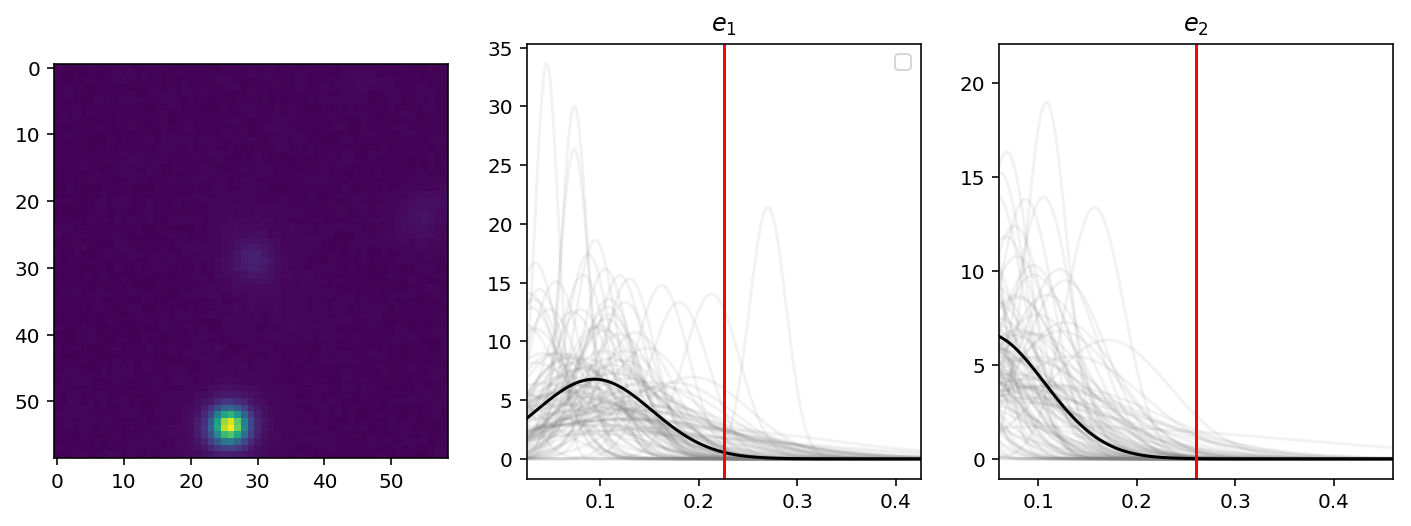

In [110]:
print('e1 is equal to: ' +str(-e1[img_nb])+' and e2 : '+str(e2[img_nb]))
fig, axes = plt.subplots(1,3, figsize = (12,4))
axes[0].imshow(images_noisy[img_nb,:,:,2])

x = np.linspace(-1,1, 1000)

for i in range (100):   
    axes[1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)   
    axes[2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,i], e2_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)

axes[1].plot(x, gaussian(np.mean(e1_out_mean_bnn_noisy[img_nb,:]), np.mean(e1_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)   
axes[2].plot(x, gaussian(np.mean(e2_out_mean_bnn_noisy[img_nb,:]), np.mean(e2_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)
    

axes[1].axvline(-e1[img_nb], color = 'r')
axes[2].axvline(e2[img_nb], color = 'r')
axes[1].set_xlim(-e1[img_nb]-0.2,-e1[img_nb]+0.2)
axes[2].set_xlim(e2[img_nb]-0.2,e2[img_nb]+0.2)
axes[1].set_title('$e_1$')
axes[2].set_title('$e_2$')
axes[1].legend()

Could be understood as a very bright galaxy is on the image, something that the model is troubling to deal with as it did not see this in its training set.

e1 is equal to: 0.18072651633781117 and e2 : -0.6539580728323495
e1 is equal to: 0.06084804362534251 and e2 : 0.14031417760970927
e1 is equal to: -0.521462974011675 and e2 : 0.2074555027714428
e1 is equal to: -0.33328399117823243 and e2 : 0.5317118803028609
e1 is equal to: -0.01210057182763586 and e2 : -0.009122904136179165
e1 is equal to: 0.013294338554872321 and e2 : -0.1295201308709439
e1 is equal to: -0.14613260640641598 and e2 : -0.08536828664117768
e1 is equal to: 0.20806321628873464 and e2 : 0.04310568219222864
e1 is equal to: -0.023471736093119512 and e2 : -0.09209458448263035
e1 is equal to: 0.22536707340490528 and e2 : 0.2605989087122399


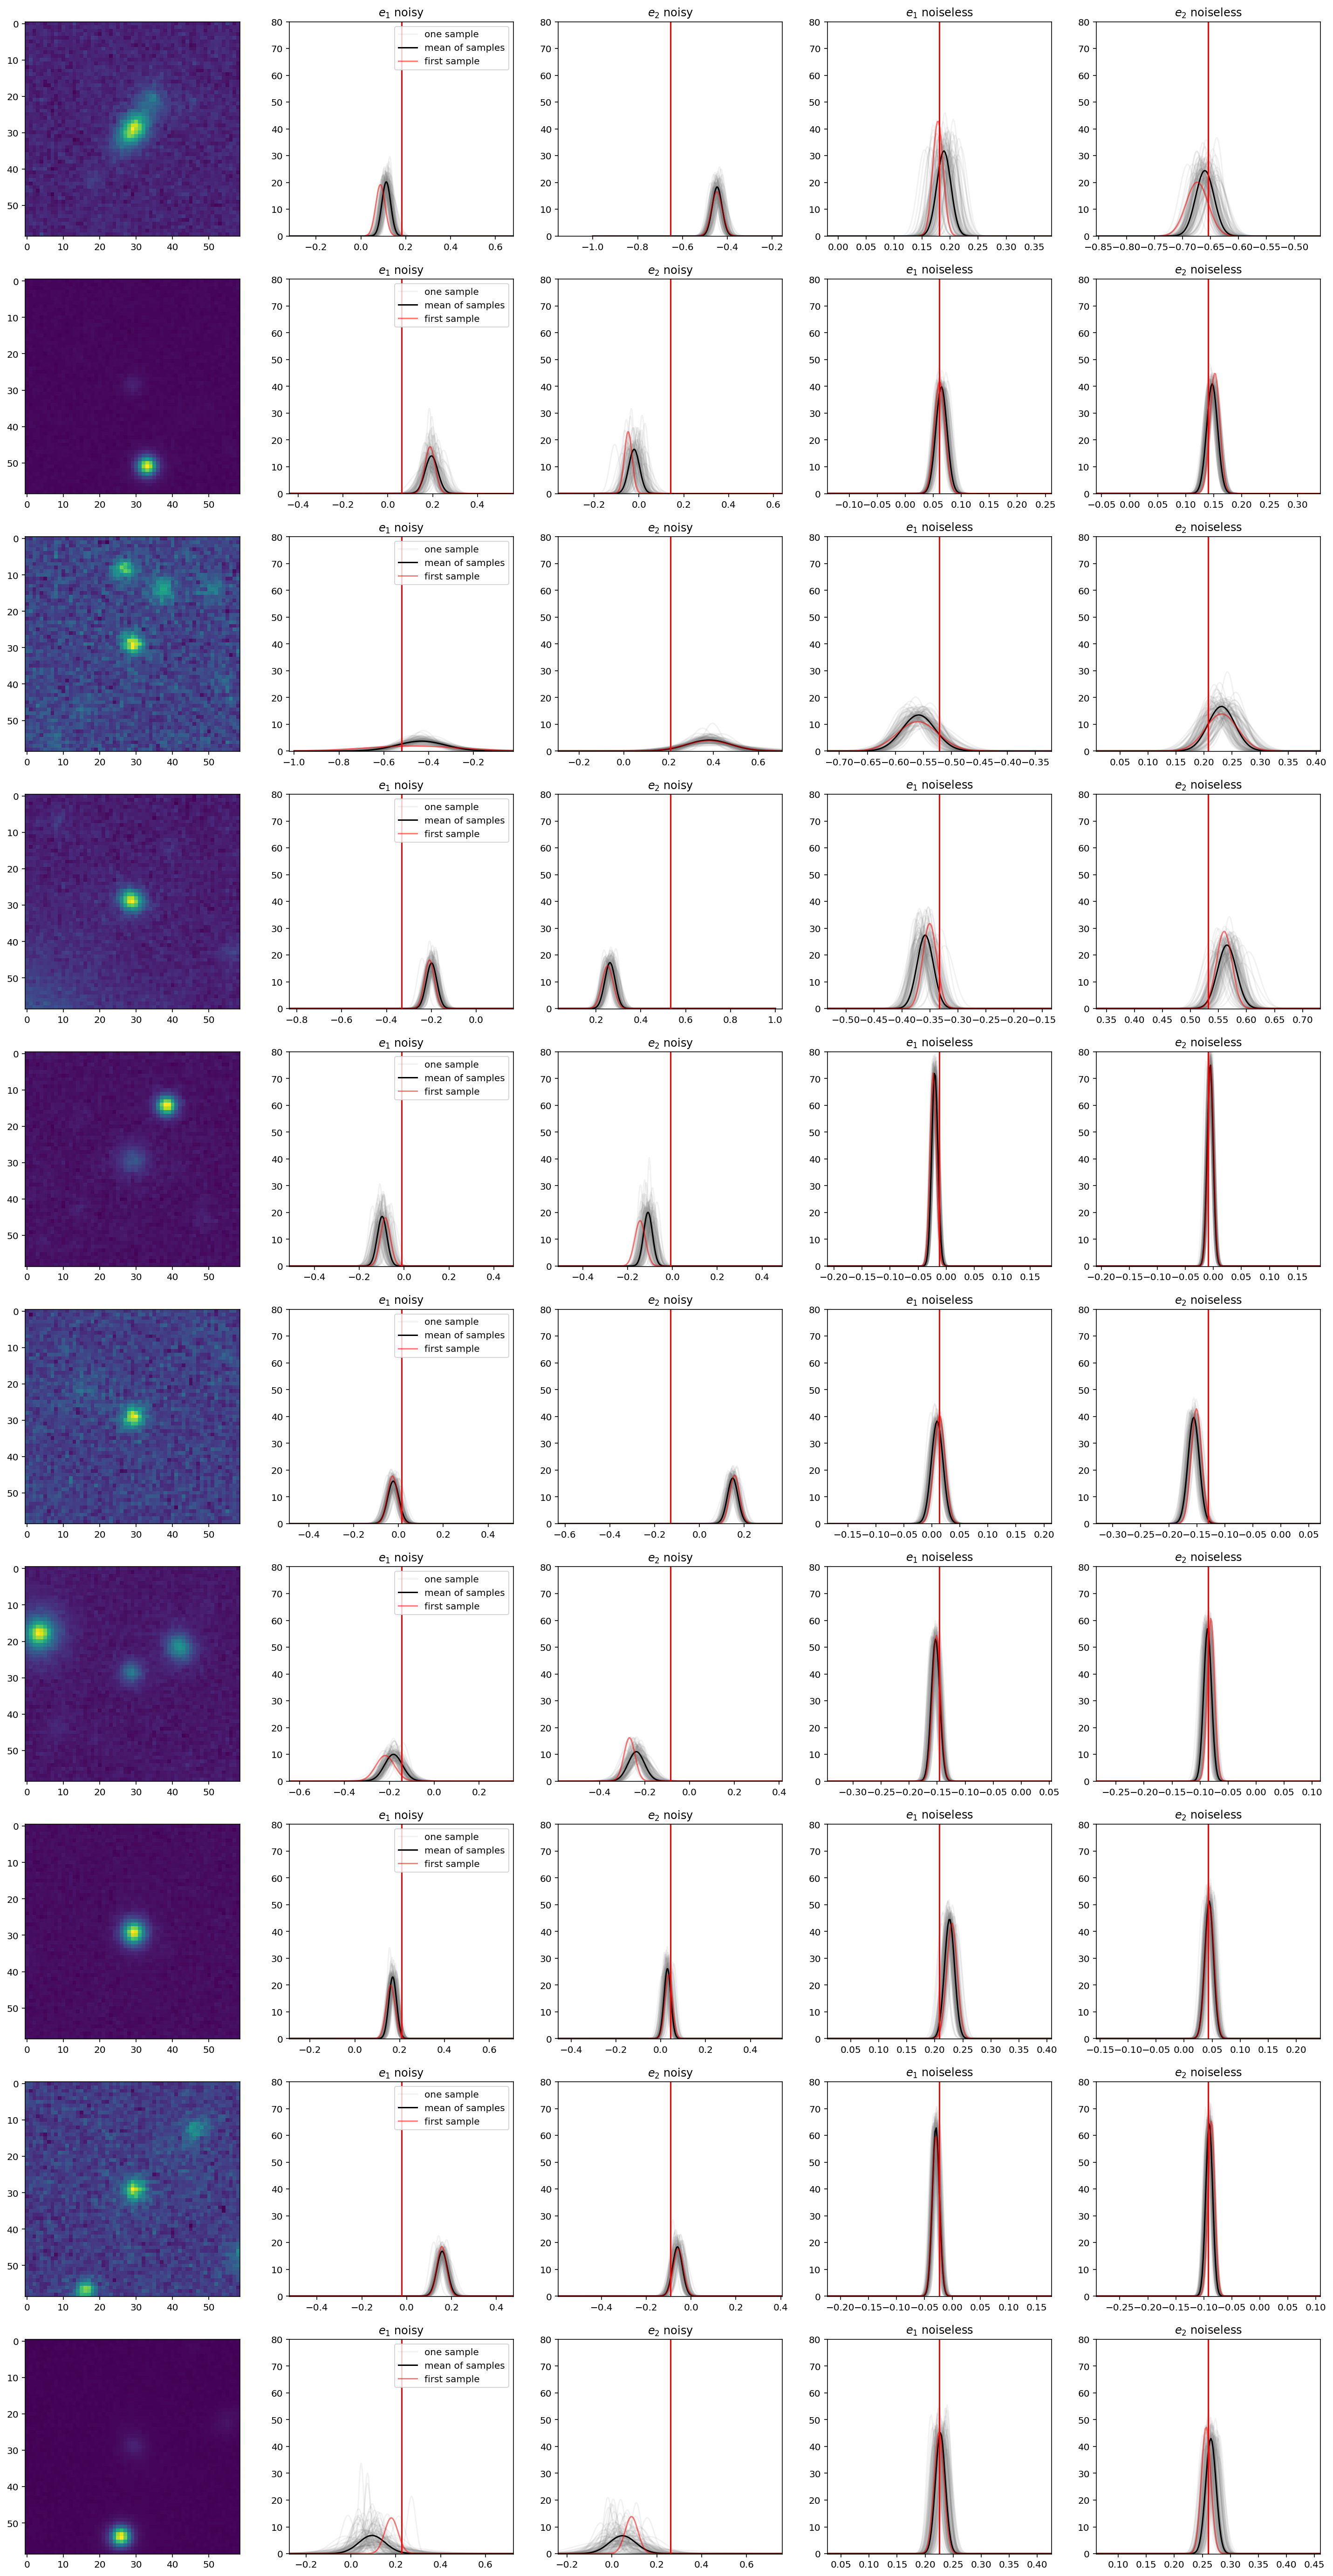

In [122]:
fig, axes = plt.subplots(10,5, figsize = (25,50))

x = np.linspace(-1,1, 1000)
for img_nb in range (10):
    print('e1 is equal to: ' +str(-e1[img_nb])+' and e2 : '+str(e2[img_nb]))
    axes[img_nb,0].imshow(images_noisy[img_nb,:,:,2])
    for i in range (100):   
         
        axes[img_nb,2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,i], e2_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)
        axes[img_nb,3].plot(x, gaussian(e1_out_mean_bnn[img_nb,i], e1_out_std_bnn[img_nb,i]), color = 'grey', alpha = 0.1)   
        axes[img_nb,4].plot(x, gaussian(e2_out_mean_bnn[img_nb,i], e2_out_std_bnn[img_nb,i]), color = 'grey', alpha = 0.1)
        if i == 99:
            axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1, label = 'one sample')  
        else:
            axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)  

    axes[img_nb,1].plot(x, gaussian(np.mean(e1_out_mean_bnn_noisy[img_nb,:]), np.mean(e1_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1, label = 'mean of samples')   
    axes[img_nb,2].plot(x, gaussian(np.mean(e2_out_mean_bnn_noisy[img_nb,:]), np.mean(e2_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)
    axes[img_nb,3].plot(x, gaussian(np.mean(e1_out_mean_bnn[img_nb,:]), np.mean(e1_out_std_bnn[img_nb,:])), color = 'black', alpha = 1)   
    axes[img_nb,4].plot(x, gaussian(np.mean(e2_out_mean_bnn[img_nb,:]), np.mean(e2_out_std_bnn[img_nb,:])), color = 'black', alpha = 1)
    
    axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,0], e1_out_std_bnn_noisy[img_nb,0]), color = 'red', alpha = 0.5, label = 'first sample')   
    axes[img_nb,2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,0], e2_out_std_bnn_noisy[img_nb,0]), color = 'red', alpha = 0.5)
    axes[img_nb,3].plot(x, gaussian(e1_out_mean_bnn[img_nb,0], e1_out_std_bnn[img_nb,0]), color = 'red', alpha = 0.5)   
    axes[img_nb,4].plot(x, gaussian(e2_out_mean_bnn[img_nb,0], e2_out_std_bnn[img_nb,0]), color = 'red', alpha = 0.5)


    axes[img_nb,1].axvline(-e1[img_nb], color = 'r')
    axes[img_nb,2].axvline(e2[img_nb], color = 'r')
    axes[img_nb,1].set_xlim(-e1[img_nb]-0.5,-e1[img_nb]+0.5)
    axes[img_nb,2].set_xlim(e2[img_nb]-0.5,e2[img_nb]+0.5)
    axes[img_nb,1].set_title('$e_1$ noisy')
    axes[img_nb,2].set_title('$e_2$ noisy')
    axes[img_nb,1].legend()
    
    axes[img_nb,3].axvline(-e1[img_nb], color = 'r')
    axes[img_nb,4].axvline(e2[img_nb], color = 'r')
    axes[img_nb,3].set_xlim(-e1[img_nb]-0.2,-e1[img_nb]+0.2)
    axes[img_nb,4].set_xlim(e2[img_nb]-0.2,e2[img_nb]+0.2)
    axes[img_nb,3].set_title('$e_1$ noiseless')
    axes[img_nb,4].set_title('$e_2$ noiseless')
    
    
    axes[img_nb,1].set_ylim(-0.1,80)
    axes[img_nb,2].set_ylim(-0.1,80)
    axes[img_nb,3].set_ylim(-0.1,80)
    axes[img_nb,4].set_ylim(-0.1,80)

In [130]:
print(np.mean(-e1[:1000]), np.mean(e1_out_mean_bnn))
print(np.mean(e2[:1000]), np.mean(e2_out_mean_bnn))

-0.005986517713405567 -0.04033749734982848
-0.006380757265538057 0.025477743778377773


In [136]:
np.average(e1_out_mean_no_psf, weights=1/e1_out_std_no_psf)

-0.007877187441171147

In [137]:
np.average(e2_out_mean_no_psf, weights=1/e2_out_std_no_psf)

-0.01138578500863725

## Combination of posteriors to recover the mean $\gamma_1$ and $\gamma_2$ of the 10 galaxy sample

In [14]:
N = 100
n_images = 10
n_img_per_loop = 10

std_e1_epistemic_noiseless=[]
std_e2_epistemic_noiseless=[]

e1_out_mean = []
e2_out_mean = []

for k in range (int(n_images/n_img_per_loop)):
    images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
    images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
    psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
    print(k)
    image_array = np.zeros((n_img_per_loop*N,59,59,6))
    psf_array = np.zeros((n_img_per_loop*N,59,59,6))

    for z in range (N):
        image_array[z*n_img_per_loop:(z+1)*n_img_per_loop] =  images[k*n_img_per_loop:(k+1)*n_img_per_loop]
        psf_array[z*n_img_per_loop:(z+1)*n_img_per_loop] =  psf[k*n_img_per_loop:(k+1)*n_img_per_loop]

    
    output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])
    e1_mean = K.get_value(output_v1.mean())[:,0]
    e2_mean = K.get_value(output_v1.mean())[:,1]
    e1_std = K.get_value(output_v1.stddev())[:,0]
    e2_std = K.get_value(output_v1.stddev())[:,1]
    
    #del image_array, psf_array

    e1_out_mean_bnn = np.zeros((n_img_per_loop,N))
    e2_out_mean_bnn = np.zeros((n_img_per_loop,N))
    e1_out_std_bnn = np.zeros((n_img_per_loop,N))
    e2_out_std_bnn = np.zeros((n_img_per_loop,N))

    for i in range (N):
        for k in range (n_img_per_loop):
            e1_out_mean_bnn[k,i] = e1_mean[k+i*n_img_per_loop]
            e2_out_mean_bnn[k,i] = e2_mean[k+i*n_img_per_loop]

            e1_out_std_bnn[k,i] = e1_std[k+i*n_img_per_loop]
            e2_out_std_bnn[k,i] = e2_std[k+i*n_img_per_loop]
    
    #del e1_mean, e2_mean, e1_std, e2_std
    
    for i in range(n_img_per_loop):
        e1_out_mean.append(np.mean(e1_out_mean_bnn[i]))
        e2_out_mean.append(np.mean(e2_out_mean_bnn[i]))
        std_e1_epistemic_noiseless.append(np.std(e1_out_std_bnn[i]))
        std_e2_epistemic_noiseless.append(np.std(e2_out_std_bnn[i]))
    print(np.array(e1_out_mean).shape)
    #del e1_out_mean_bnn, e2_out_mean_bnn, e1_out_std_bnn, e2_out_std_bnn

0
(10,)


In [15]:
e1_out_mean_once_concat, e2_out_mean_once_concat, e1_out_std_once_concat, e2_out_std_once_concat = np.load('data/net_once_concat_noiseless.npy')
#e1_out_mean_bnn, e2_out_mean_bnn, e1_out_std_bnn, e2_out_std_bnn = np.load('data/net_bnn_noiseless.npy')
e1_out_mean_no_psf, e2_out_mean_no_psf, e1_out_std_no_psf, e2_out_std_no_psf = np.load('data/net_no_psf_noiseless.npy')

In [16]:
def gaussian(mean,std):
    return (1/(std*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean)/(2*std**2)))

In [17]:
np.mean(e1_out_mean_bnn),np.mean(e1_out_std_bnn), np.mean(e1[:10]), np.mean(np.array(data['shear_1'])[:10])

(-0.03481853988952935,
 0.008300966595998034,
 0.03481526913054127,
 0.0016095629209405605)

-0.03481853988952935 -0.03481526913054127 0.021709608167409897 0.021312217262520063


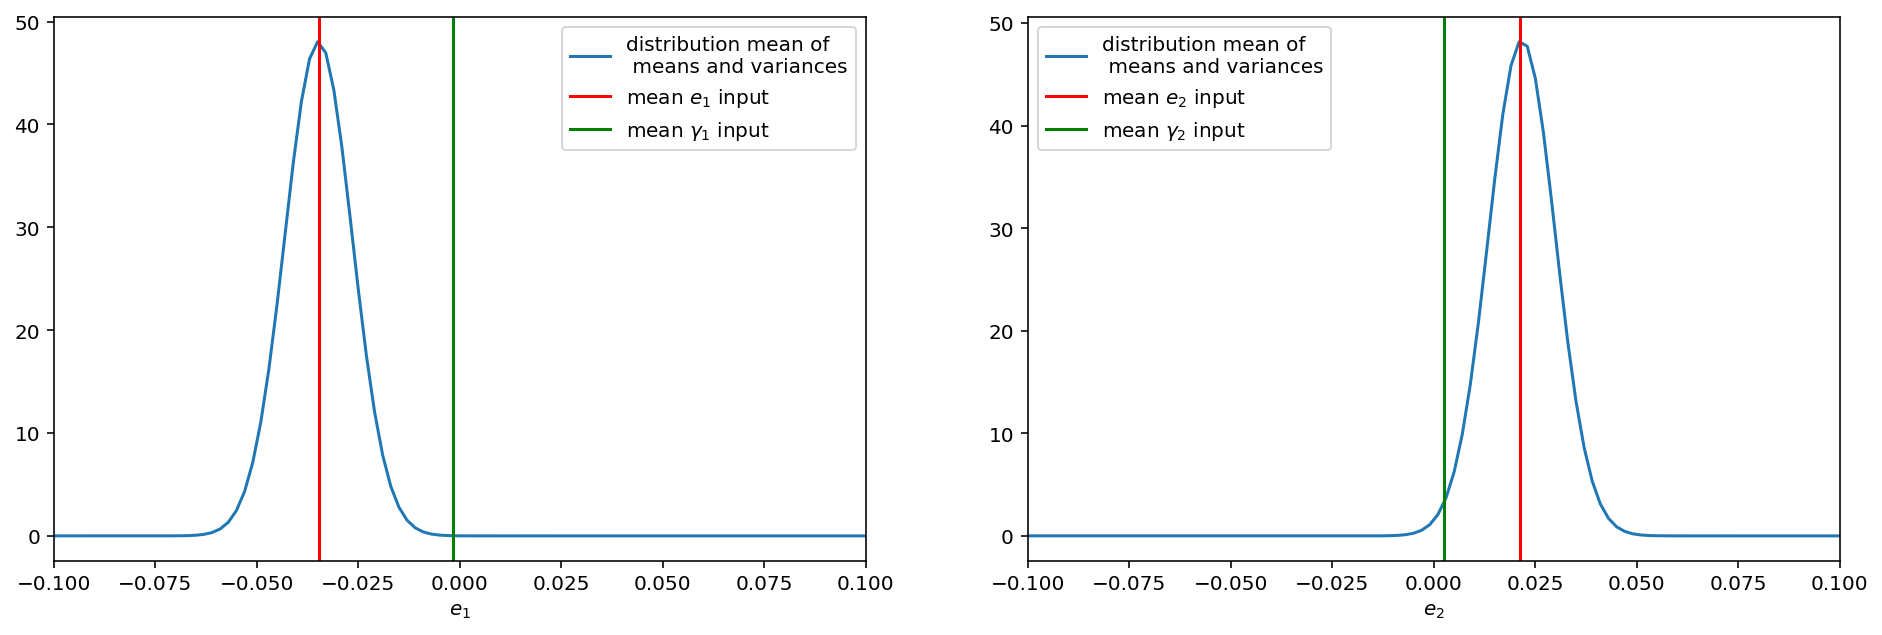

In [18]:
x = np.linspace(-1,1, 1000)

fig, ax = plt.subplots(1,2, figsize = (16,5))
ax[0].plot(x,gaussian(np.mean(e1_out_mean_bnn), np.mean(e1_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[0].set_xlim(-0.1, 0.1)
ax[0].axvline(np.mean(-e1[:10]), color = 'red', label ="mean $e_1$ input")
ax[0].axvline(np.mean(-np.array(data['shear_1'])[:10]), color = 'green', label = "mean $\gamma_1$ input")
ax[0].set_xlabel('$e_1$')

ax[1].plot(x,gaussian(np.mean(e2_out_mean_bnn), np.mean(e2_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[1].set_xlim(-0.1, 0.1)
ax[1].axvline(np.mean(e2[:10]), color = 'red', label ="mean $e_2$ input")
ax[1].axvline(np.mean(-np.array(data['shear_2'])[:10]), color = 'green', label = "mean $\gamma_2$ input")
ax[1].set_xlabel('$e_2$')

ax[0].legend()
ax[1].legend()
print(np.mean(e1_out_mean_bnn), -np.mean(e1[:10]), np.mean(e2_out_mean_bnn), np.mean(e2[:10]))

mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_bnn,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_bnn,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_bnn,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_bnn,e2_out_std_no_psf]

-0.034818539889529355 -0.03481526913054127 0.0217096081674099 0.021312217262520063


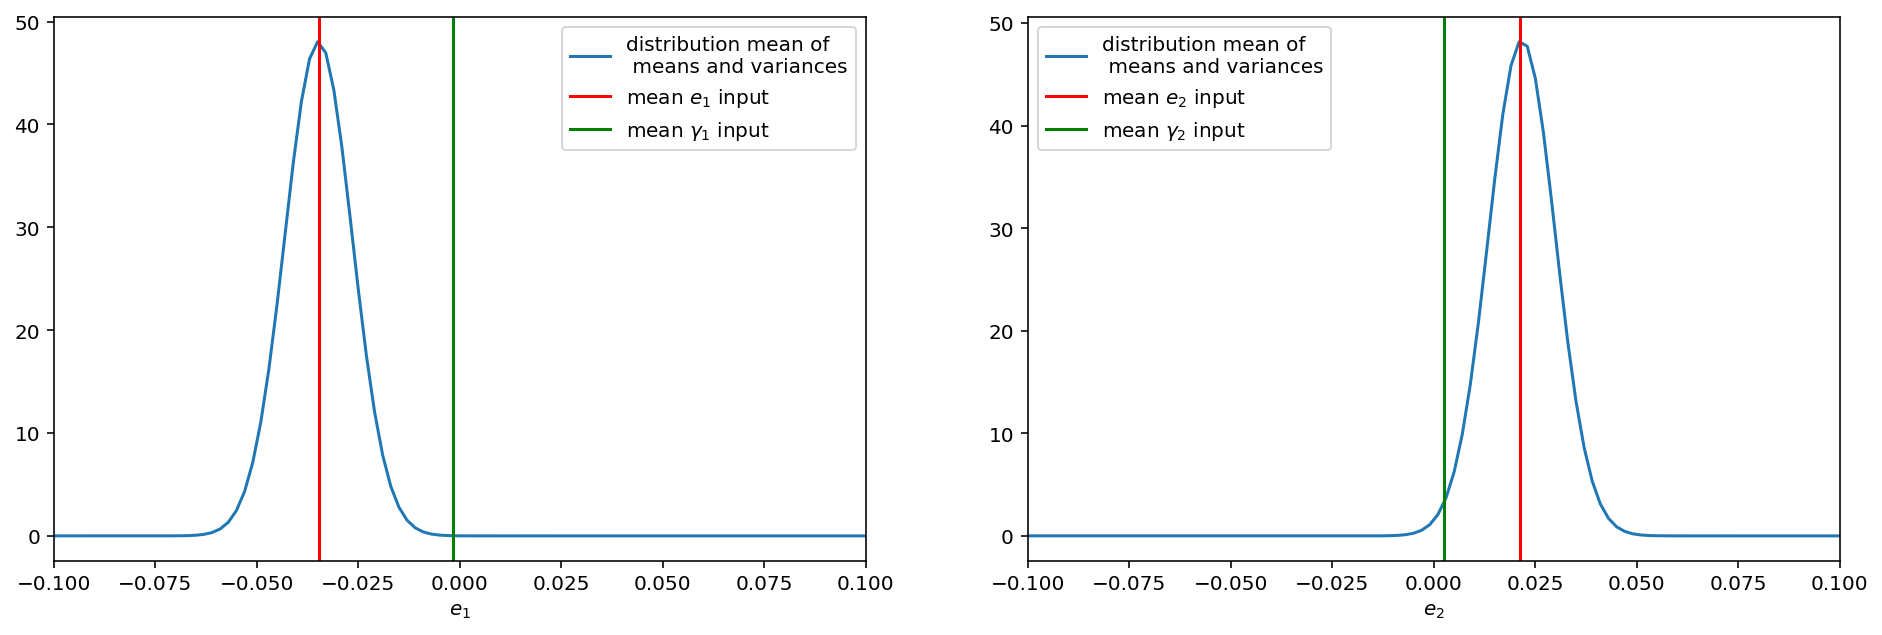

In [19]:
x = np.linspace(-1,1, 1000)

fig, ax = plt.subplots(1,2, figsize = (16,5))
ax[0].plot(x,gaussian(np.mean(e1_out_mean), np.mean(e1_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[0].set_xlim(-0.1, 0.1)
ax[0].axvline(np.mean(-e1[:10]), color = 'red', label ="mean $e_1$ input")
ax[0].axvline(np.mean(-np.array(data['shear_1'])[:10]), color = 'green', label = "mean $\gamma_1$ input")
ax[0].set_xlabel('$e_1$')

ax[1].plot(x,gaussian(np.mean(e2_out_mean), np.mean(e2_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[1].set_xlim(-0.1, 0.1)
ax[1].axvline(np.mean(e2[:10]), color = 'red', label ="mean $e_2$ input")
ax[1].axvline(np.mean(-np.array(data['shear_2'])[:10]), color = 'green', label = "mean $\gamma_2$ input")
ax[1].set_xlabel('$e_2$')

ax[0].legend()
ax[1].legend()
print(np.mean(e1_out_mean), -np.mean(e1[:10]), np.mean(e2_out_mean), np.mean(e2[:10]))

-0.03481853988952935 -0.03481526913054127 0.021709608167409897 0.021312217262520063


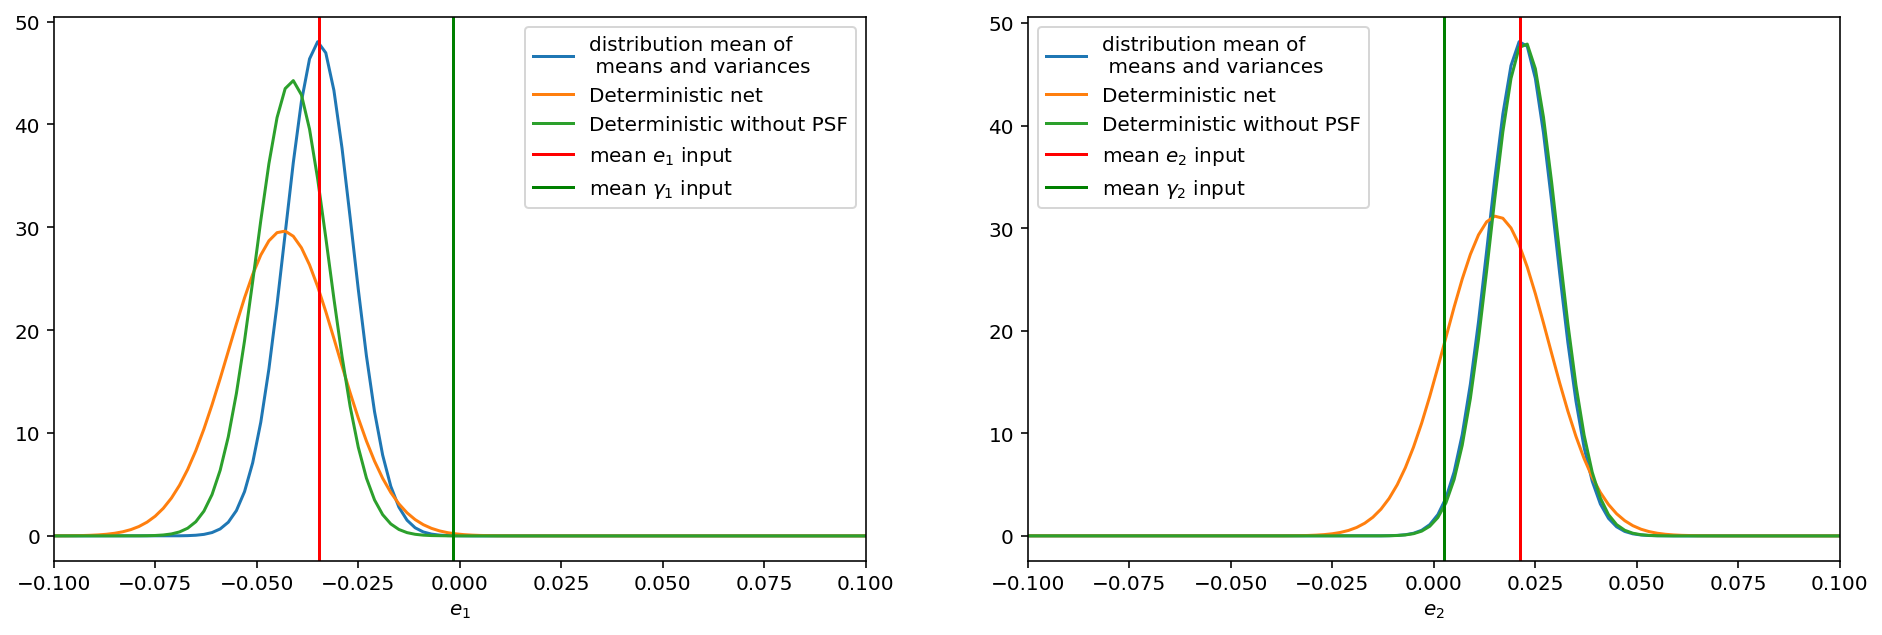

In [20]:
x = np.linspace(-1,1, 1000)

fig, ax = plt.subplots(1,2, figsize = (16,5))
ax[0].plot(x,gaussian(np.mean(e1_out_mean_bnn), np.mean(e1_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[0].plot(x,gaussian(np.mean(e1_out_mean_once_concat[:10]), np.mean(e1_out_std_once_concat[:10])), label = 'Deterministic net')
ax[0].plot(x,gaussian(np.mean(e1_out_mean_no_psf[:10]), np.mean(e1_out_std_no_psf[:10])), label ='Deterministic without PSF')
ax[0].set_xlim(-0.1, 0.1)
ax[0].axvline(np.mean(-e1[:10]), color = 'red', label ="mean $e_1$ input")
ax[0].axvline(np.mean(-np.array(data['shear_1'])[:10]), color = 'green', label = "mean $\gamma_1$ input")
ax[0].set_xlabel('$e_1$')

ax[1].plot(x,gaussian(np.mean(e2_out_mean_bnn), np.mean(e2_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[1].plot(x,gaussian(np.mean(e2_out_mean_once_concat[:10]), np.mean(e2_out_std_once_concat[:10])), label = 'Deterministic net')
ax[1].plot(x,gaussian(np.mean(e2_out_mean_no_psf[:10]), np.mean(e2_out_std_no_psf[:10])), label ='Deterministic without PSF')
ax[1].set_xlim(-0.1, 0.1)
ax[1].axvline(np.mean(e2[:10]), color = 'red', label ="mean $e_2$ input")
ax[1].axvline(np.mean(-np.array(data['shear_2'])[:10]), color = 'green', label = "mean $\gamma_2$ input")
ax[1].set_xlabel('$e_2$')

ax[0].legend()
ax[1].legend()
print(np.mean(e1_out_mean_bnn), -np.mean(e1[:10]), np.mean(e2_out_mean_bnn), np.mean(e2[:10]))

#### Weighted mean by predictive uncertainty

In [21]:
mean_pred_std_e1 = np.zeros((10))
mean_pred_std_e2 = np.zeros((10))
for i in range (10): 
    mean_pred_std_e1[i] = np.mean(e1_out_std_bnn[i,:])
    mean_pred_std_e2[i] = np.mean(e2_out_std_bnn[i,:])

In [22]:
tot_std_e1 = np.sum(mean_pred_std_e1)
tot_std_e2 = np.sum(mean_pred_std_e2)

In [23]:
mean_weighted_e1 =0
mean_weighted_e2 =0
for i in range (10):
    mean_weighted_e1 += np.mean(e1_out_mean_bnn[i,:])*mean_pred_std_e1[i]/tot_std_e1
    mean_weighted_e2 += np.mean(e2_out_mean_bnn[i,:])*mean_pred_std_e2[i]/tot_std_e2

-0.10145985641787743 -0.03481526913054127 0.03753830791830983 0.021312217262520063


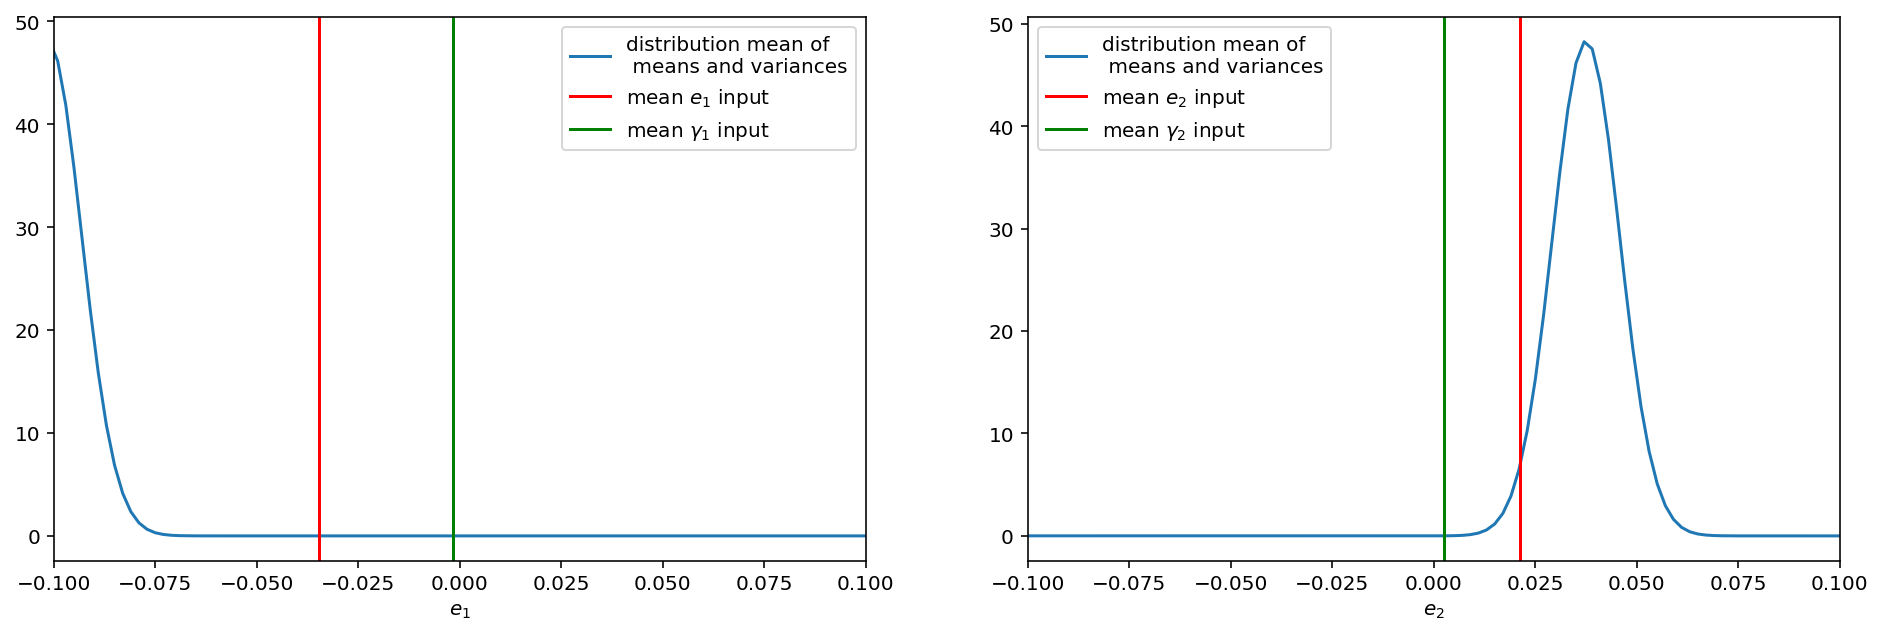

In [24]:
x = np.linspace(-1,1, 1000)

fig, ax = plt.subplots(1,2, figsize = (16,5))
ax[0].plot(x,gaussian(mean_weighted_e1, np.mean(e1_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[0].set_xlim(-0.1, 0.1)
ax[0].axvline(np.mean(-e1[:10]), color = 'red', label ="mean $e_1$ input")
ax[0].axvline(np.mean(-np.array(data['shear_1'])[:10]), color = 'green', label = "mean $\gamma_1$ input")
ax[0].set_xlabel('$e_1$')

ax[1].plot(x,gaussian(mean_weighted_e2, np.mean(e2_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[1].set_xlim(-0.1, 0.1)
ax[1].axvline(np.mean(e2[:10]), color = 'red', label ="mean $e_2$ input")
ax[1].axvline(np.mean(-np.array(data['shear_2'])[:10]), color = 'green', label = "mean $\gamma_2$ input")
ax[1].set_xlabel('$e_2$')

ax[0].legend()
ax[1].legend()
print(mean_weighted_e1, -np.mean(e1[:10]), mean_weighted_e2, np.mean(e2[:10]))

#### Weighted mean by epistemic uncertainty

In [25]:
tot_std_e1_epistemic = np.sum(std_e1_epistemic_noiseless)
tot_std_e2_epistemic = np.sum(std_e2_epistemic_noiseless)

In [26]:
mean_weighted_e1_epistemic =0
mean_weighted_e2_epistemic =0
for i in range (10):
    mean_weighted_e1_epistemic += np.mean(e1_out_mean_bnn[i,:])*std_e1_epistemic_noiseless[i]/tot_std_e1_epistemic
    mean_weighted_e2_epistemic += np.mean(e2_out_mean_bnn[i,:])*std_e2_epistemic_noiseless[i]/tot_std_e2_epistemic

-0.18900965502247302 -0.03481526913054127 0.043344763940951776 0.021312217262520063


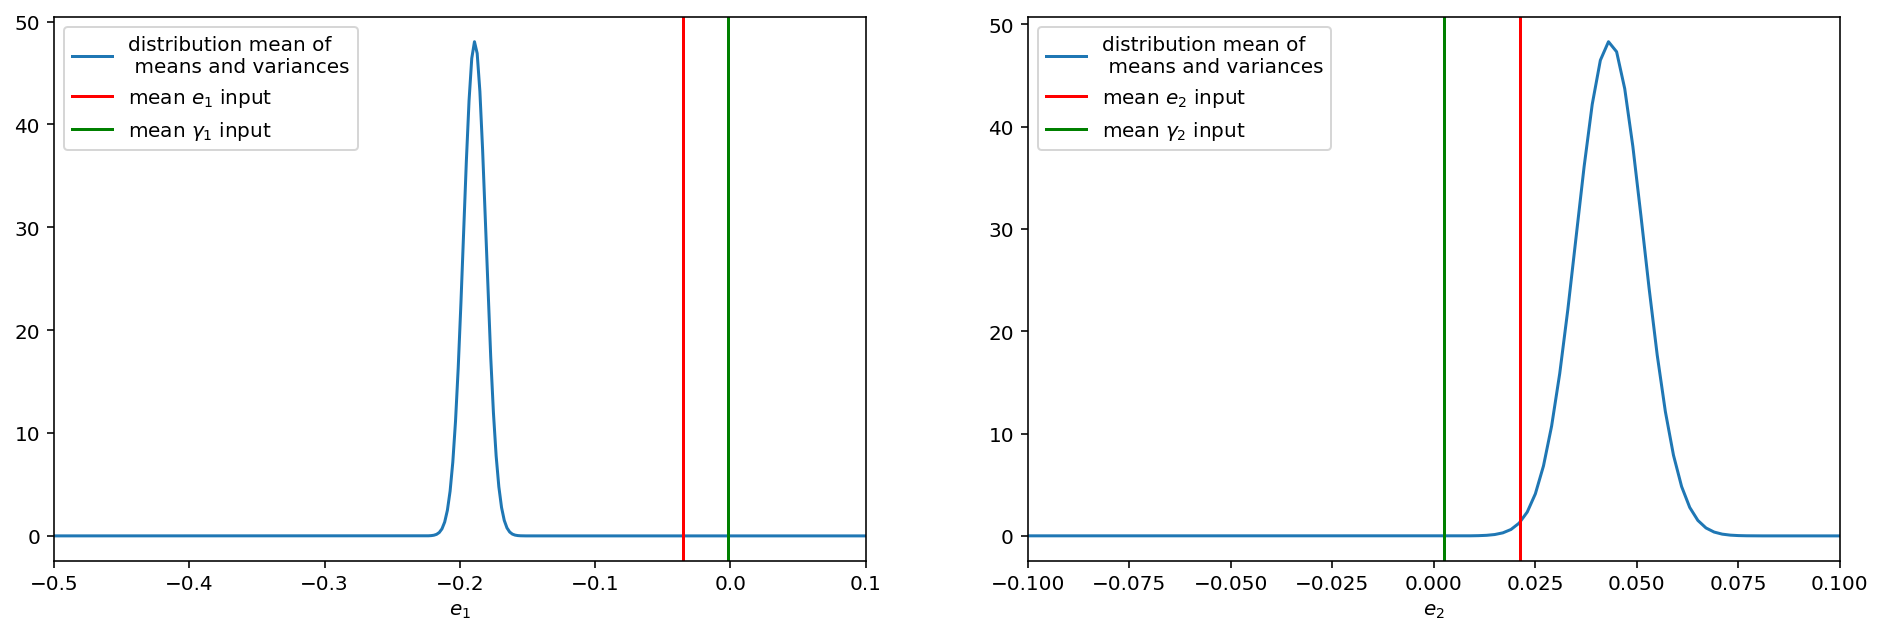

In [27]:
x = np.linspace(-1,1, 1000)

fig, ax = plt.subplots(1,2, figsize = (16,5))
ax[0].plot(x,gaussian(mean_weighted_e1_epistemic, np.mean(e1_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[0].set_xlim(-0.5, 0.1)
ax[0].axvline(np.mean(-e1[:10]), color = 'red', label ="mean $e_1$ input")
ax[0].axvline(np.mean(-np.array(data['shear_1'])[:10]), color = 'green', label = "mean $\gamma_1$ input")
ax[0].set_xlabel('$e_1$')

ax[1].plot(x,gaussian(mean_weighted_e2_epistemic, np.mean(e2_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[1].set_xlim(-0.1, 0.1)
ax[1].axvline(np.mean(e2[:10]), color = 'red', label ="mean $e_2$ input")
ax[1].axvline(np.mean(-np.array(data['shear_2'])[:10]), color = 'green', label = "mean $\gamma_2$ input")
ax[1].set_xlabel('$e_2$')

ax[0].legend()
ax[1].legend()
print(mean_weighted_e1_epistemic, -np.mean(e1[:10]), mean_weighted_e2_epistemic, np.mean(e2[:10]))

## Add shear with galsim

In [10]:
import galsim

In [11]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')

In [70]:
images.shape

(10000, 59, 59, 6)

In [103]:
image_galsim = galsim.Image(images[0,:,:,0], copy=True)
test = galsim.InterpolatedImage(image_galsim,scale = 0.2)
s = galsim.Shear(g1=-0.01, g2=0.)

In [104]:
test = test.shear(s)

image = galsim.ImageF(59, 59, scale=0.2)
_ = test.drawImage(image=image)
test_img = image.array.data

In [14]:
psf_image = galsim.Image(psf[0,:,:,0], copy=True)
galsim_psf = galsim.InterpolatedImage(psf_image,scale = 0.2)
inv_psf = galsim.Deconvolve(galsim_psf)

image_galsim = galsim.Image(images[0,:,:,0], copy=True)
galsim_obj = galsim.InterpolatedImage(image_galsim,scale = 0.2)

deconv_galsim_obj = galsim.Convolve(inv_psf, galsim_obj)

gamma1 = 0.
gamma2 = 0.

s = galsim.Shear(g1=gamma1,g2=gamma2)

# Shear galsim object
deconv_galsim_obj = deconv_galsim_obj.shear(s)

# recconvolve by PSF
conv_galsim_obj = galsim.Convolve(galsim_psf, deconv_galsim_obj)

# Reconstruct image from sheared object
image = galsim.ImageF(59, 59, scale=0.2)
_ = conv_galsim_obj.drawImage(image=image)
test_img = image.array.data

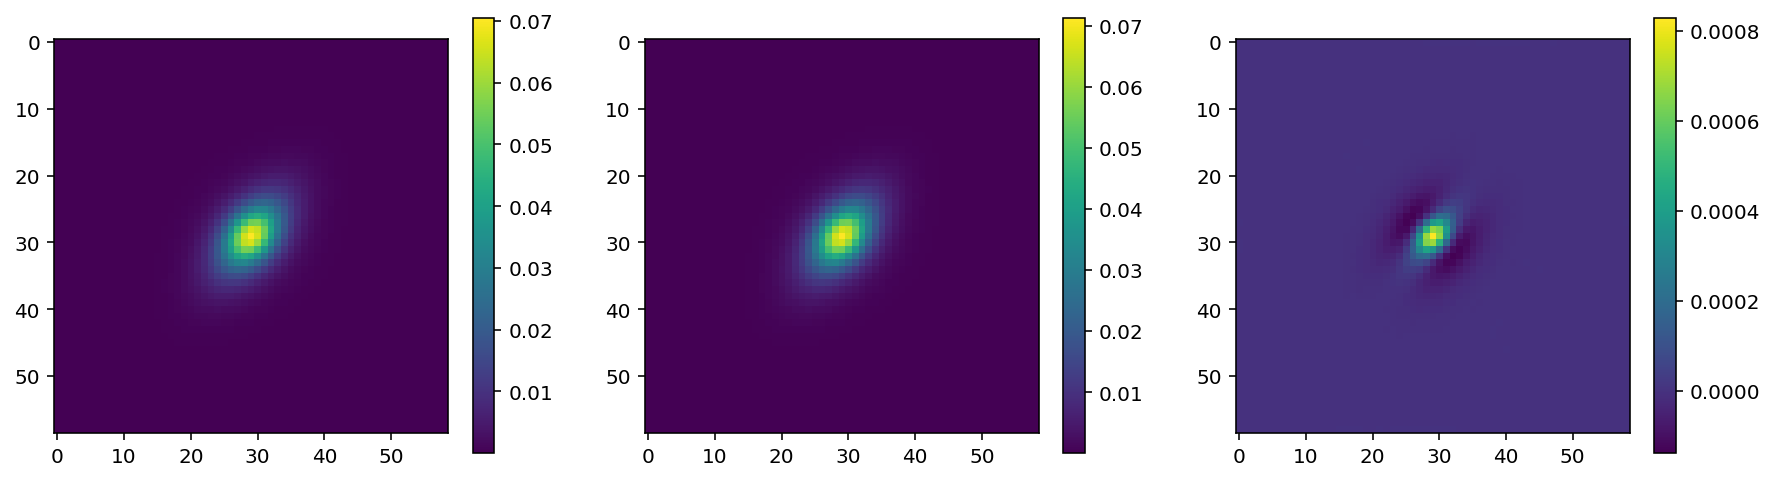

In [15]:
fig, axes = plt.subplots(1,3, figsize = (15,4))
fig1 = axes[0].imshow(test_img)
fig2 = axes[1].imshow(images[0,:,:,0])
fig3 = axes[2].imshow(images[0,:,:,0]-test_img)

fig.colorbar(fig1, ax = axes[0])
fig.colorbar(fig2, ax = axes[1])
fig.colorbar(fig3, ax = axes[2])

In [22]:
n_images = 10000
image_sheared = np.zeros((4,n_images,59,59,6))
shears = [(0.01,0), (-0.01,0), (0,0.01), (0,-0.01)]

for z, input_shear in enumerate(shears):
    for i in range (n_images):
        for k in range (len(images[0,0,0])):
            psf_image = galsim.Image(psf[i,:,:,k], copy=True)
            galsim_psf = galsim.InterpolatedImage(psf_image,scale = 0.2)
            inv_psf = galsim.Deconvolve(galsim_psf)
            
            image_galsim = galsim.Image(images[i,:,:,k], copy=True)
            galsim_obj = galsim.InterpolatedImage(image_galsim,scale = 0.2)
            
            deconv_galsim_obj = galsim.Convolve(inv_psf, galsim_obj)
            
            gamma1 = input_shear[0]
            gamma2 = input_shear[1]

            s = galsim.Shear(g1=gamma1,g2=gamma2)

            # Shear galsim object
            deconv_galsim_obj = deconv_galsim_obj.shear(s)

            # recconvolve by PSF
            conv_galsim_obj = galsim.Convolve(galsim_psf, deconv_galsim_obj)
            
            # Reconstruct image from sheared object
            image = galsim.ImageF(59, 59, scale=0.2)
            _ = conv_galsim_obj.drawImage(image=image)
            image_sheared[z,i,:,:,k] = image.array.data

In [23]:
np.save(root_dir_v1+'sheared_images.npy', image_sheared)

In [25]:
image_sheared = np.load(root_dir_v1+'sheared_images.npy', mmap_mode = 'c')

In [135]:
image_sheared.shape

(4, 10000, 59, 59, 6)

Text(0.5, 1.0, '$g(0,0)-g(0,-0.01)$')

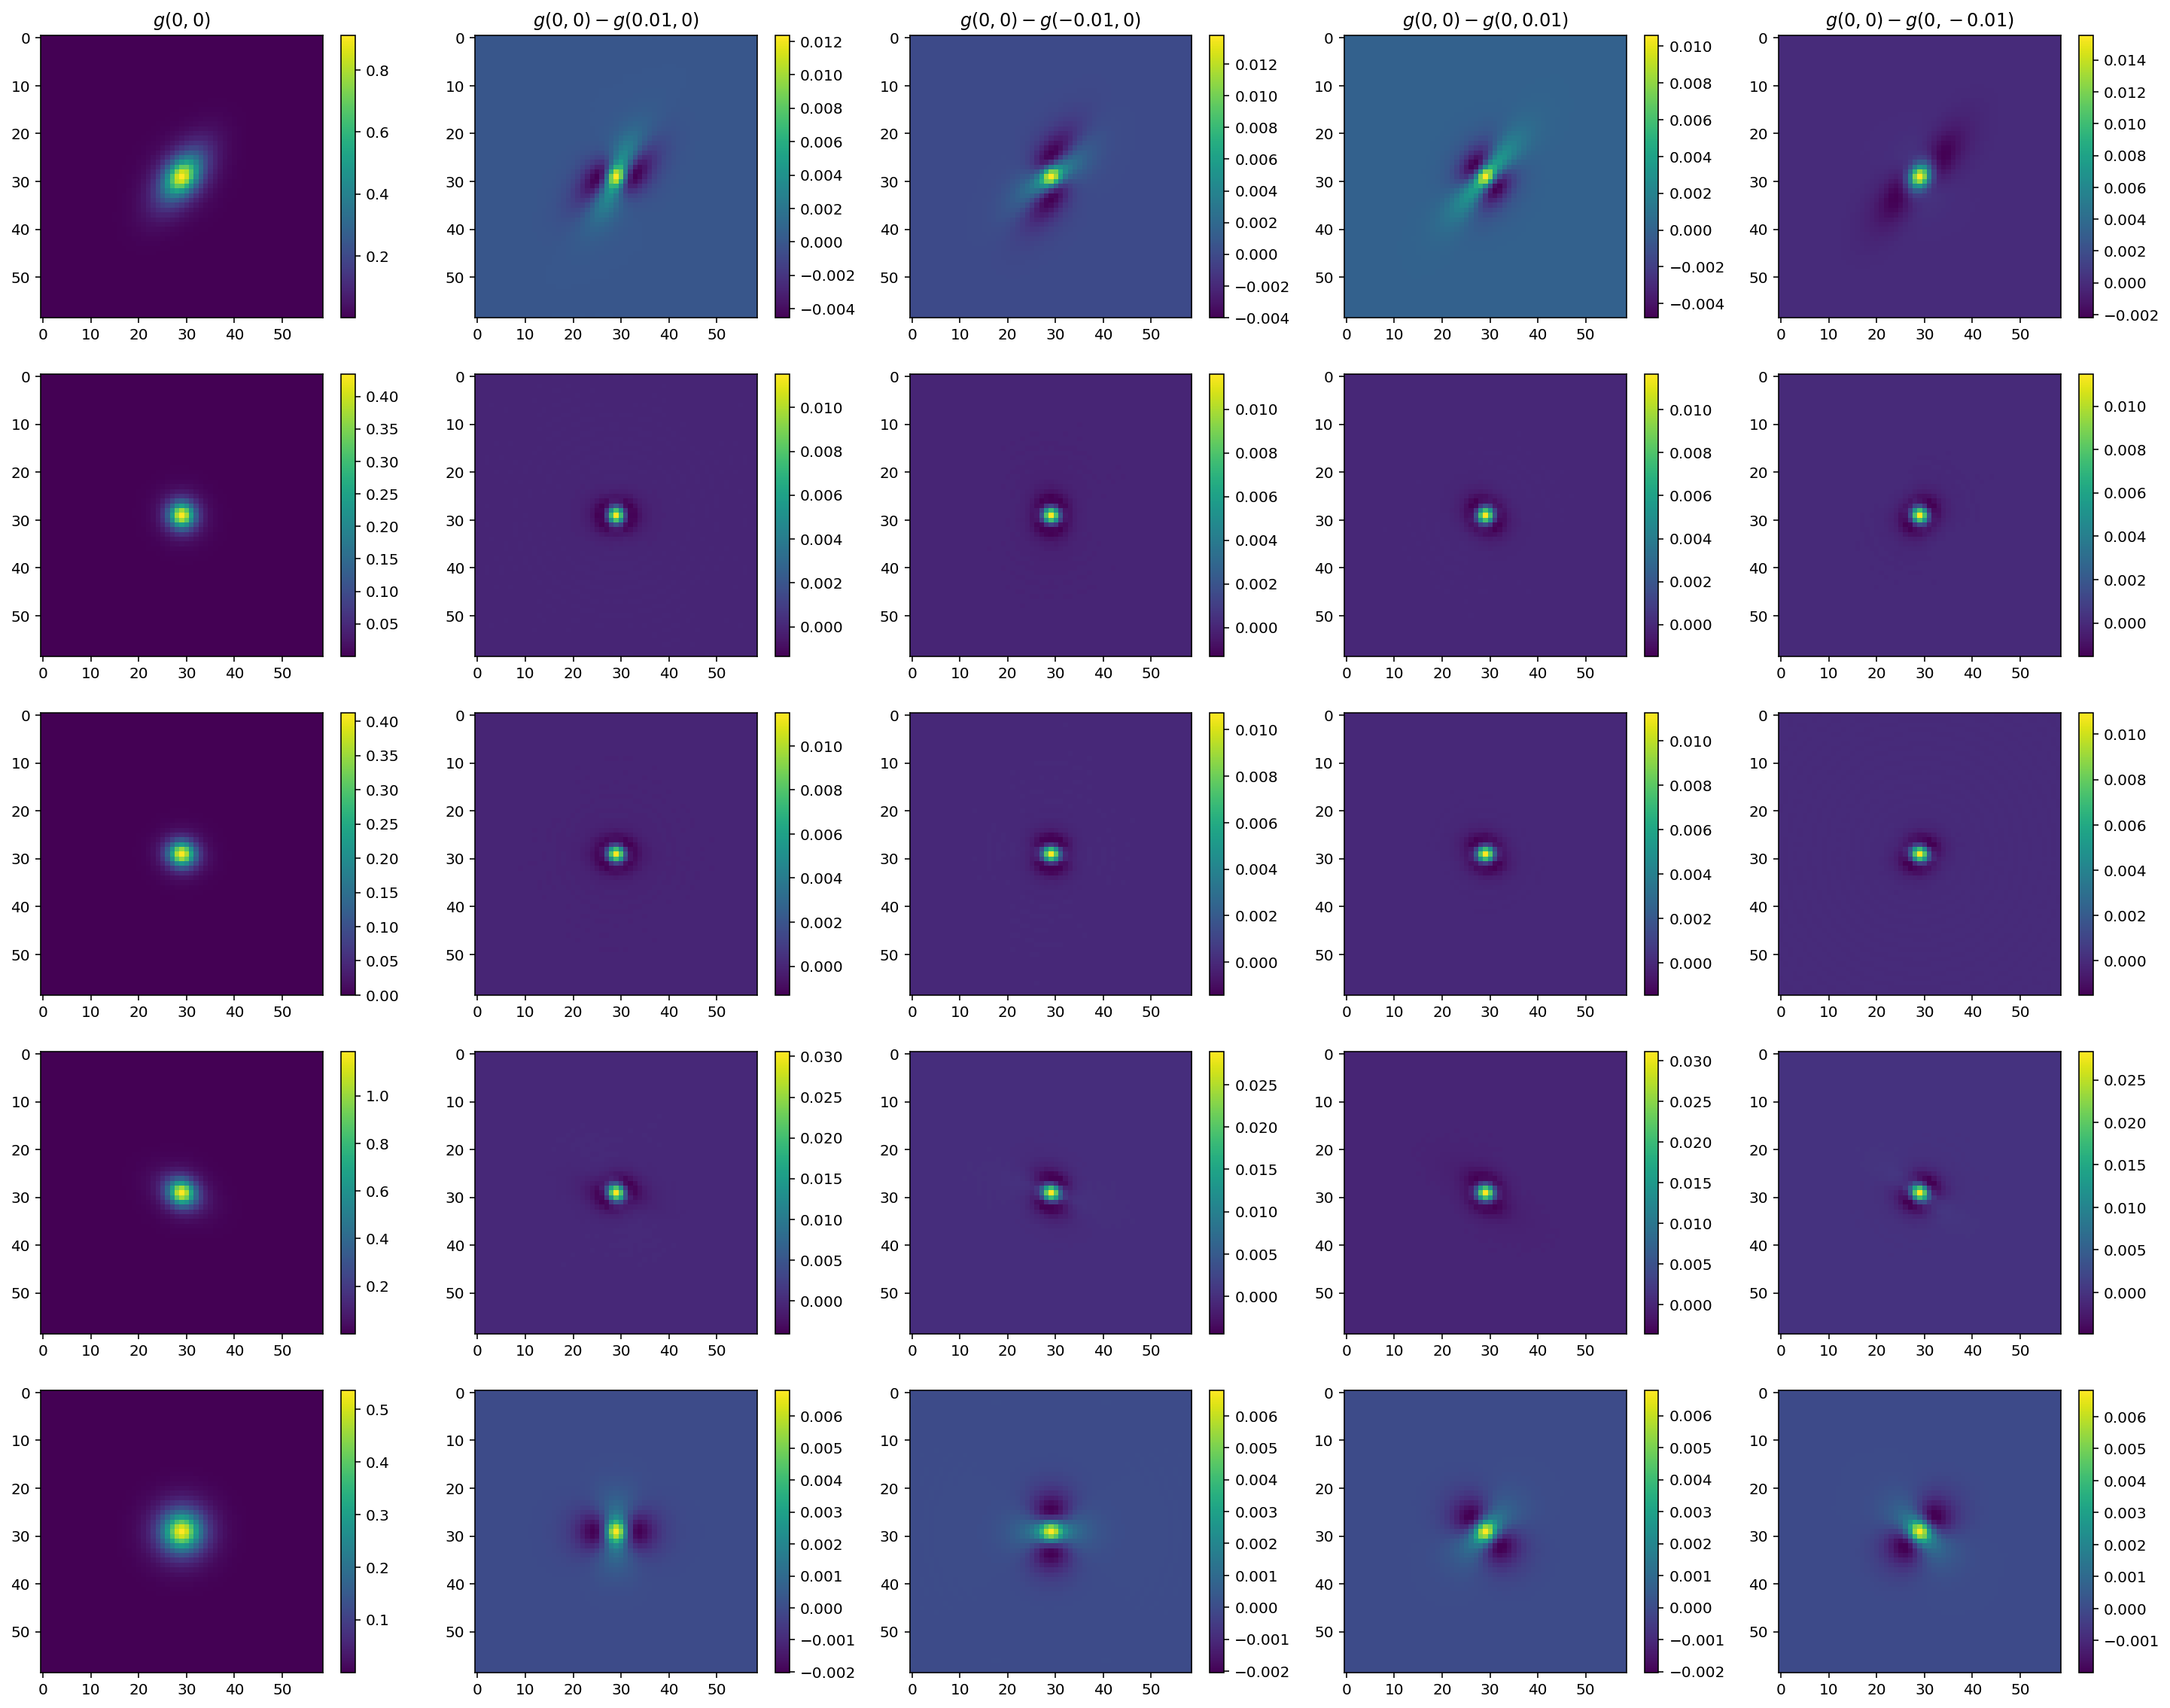

In [21]:
fig, ax = plt.subplots(5, 5, figsize = (25,20))
cm = ['RdBu_r']
      
for i in range (5):
    img = ax[i,0].imshow(images[i,:,:,2])
    fig.colorbar(img, ax=ax[i,0])
    img = ax[i,1].imshow(images[i,:,:,2]- image_sheared[0,i,:,:,2])
    fig.colorbar(img, ax=ax[i,1])
    img = ax[i,2].imshow(images[i,:,:,2]- image_sheared[1,i,:,:,2])
    fig.colorbar(img, ax=ax[i,2])
    img = ax[i,3].imshow(images[i,:,:,2]- image_sheared[2,i,:,:,2])
    fig.colorbar(img, ax=ax[i,3])
    img = ax[i,4].imshow(images[i,:,:,2]- image_sheared[3,i,:,:,2])
    fig.colorbar(img, ax=ax[i,4])
    
ax[0,0].set_title('$g(0,0)$')
ax[0,1].set_title('$g(0,0)-g(0.01,0)$')
ax[0,2].set_title('$g(0,0)-g(-0.01,0)$')
ax[0,3].set_title('$g(0,0)-g(0,0.01)$')
ax[0,4].set_title('$g(0,0)-g(0,-0.01)$')

In [121]:
output_v1 = model_bnn([tf.cast(image_sheared, tf.float32), tf.cast(psf[:10], tf.float32)])
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]

In [117]:
output_v1 = model_bnn([tf.cast(images[:10], tf.float32), tf.cast(psf[:10], tf.float32)])
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]

In [118]:
e1_mean

array([ 0.19942166,  0.06748094, -0.5247412 , -0.35179746, -0.01385379,
        0.02061924, -0.1524675 ,  0.22723408, -0.0245542 ,  0.2276539 ],
      dtype=float32)

In [120]:
-e1[:10]

array([ 0.18072652,  0.06084804, -0.52146297, -0.33328399, -0.01210057,
        0.01329434, -0.14613261,  0.20806322, -0.02347174,  0.22536707])

In [123]:
np.mean(e1_mean+e1[:10])

-0.05074583945863108

In [107]:
N = 100
n_images = 10
n_img_per_loop = 10

std_e1_epistemic_noiseless=[]
std_e2_epistemic_noiseless=[]

e1_out_mean = []
e2_out_mean = []

for k in range (int(n_images/n_img_per_loop)):
    images = image_sheared
    psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
    image_array = np.zeros((n_img_per_loop*N,59,59,6))
    psf_array = np.zeros((n_img_per_loop*N,59,59,6))

    for z in range (N):
        image_array[z*n_img_per_loop:(z+1)*n_img_per_loop] =  images[k*n_img_per_loop:(k+1)*n_img_per_loop]
        psf_array[z*n_img_per_loop:(z+1)*n_img_per_loop] =  psf[k*n_img_per_loop:(k+1)*n_img_per_loop]

    
    output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])
    e1_mean = K.get_value(output_v1.mean())[:,0]
    e2_mean = K.get_value(output_v1.mean())[:,1]
    e1_std = K.get_value(output_v1.stddev())[:,0]
    e2_std = K.get_value(output_v1.stddev())[:,1]
    
    #del image_array, psf_array

    e1_out_mean_bnn = np.zeros((n_img_per_loop,N))
    e2_out_mean_bnn = np.zeros((n_img_per_loop,N))
    e1_out_std_bnn = np.zeros((n_img_per_loop,N))
    e2_out_std_bnn = np.zeros((n_img_per_loop,N))

    for i in range (N):
        for k in range (n_img_per_loop):
            e1_out_mean_bnn[k,i] = e1_mean[k+i*n_img_per_loop]
            e2_out_mean_bnn[k,i] = e2_mean[k+i*n_img_per_loop]

            e1_out_std_bnn[k,i] = e1_std[k+i*n_img_per_loop]
            e2_out_std_bnn[k,i] = e2_std[k+i*n_img_per_loop]
    
    #del e1_mean, e2_mean, e1_std, e2_std
    
    for i in range(n_img_per_loop):
        e1_out_mean.append(np.mean(e1_out_mean_bnn[i]))
        e2_out_mean.append(np.mean(e2_out_mean_bnn[i]))
        std_e1_epistemic_noiseless.append(np.std(e1_out_std_bnn[i]))
        std_e2_epistemic_noiseless.append(np.std(e2_out_std_bnn[i]))
    print(np.array(e1_out_mean).shape)
    #del e1_out_mean_bnn, e2_out_mean_bnn, e1_out_std_bnn, e2_out_std_bnn

(10,)


-0.08360854451032355 -0.03481526913054127 0.018769135155715048 0.021312217262520063


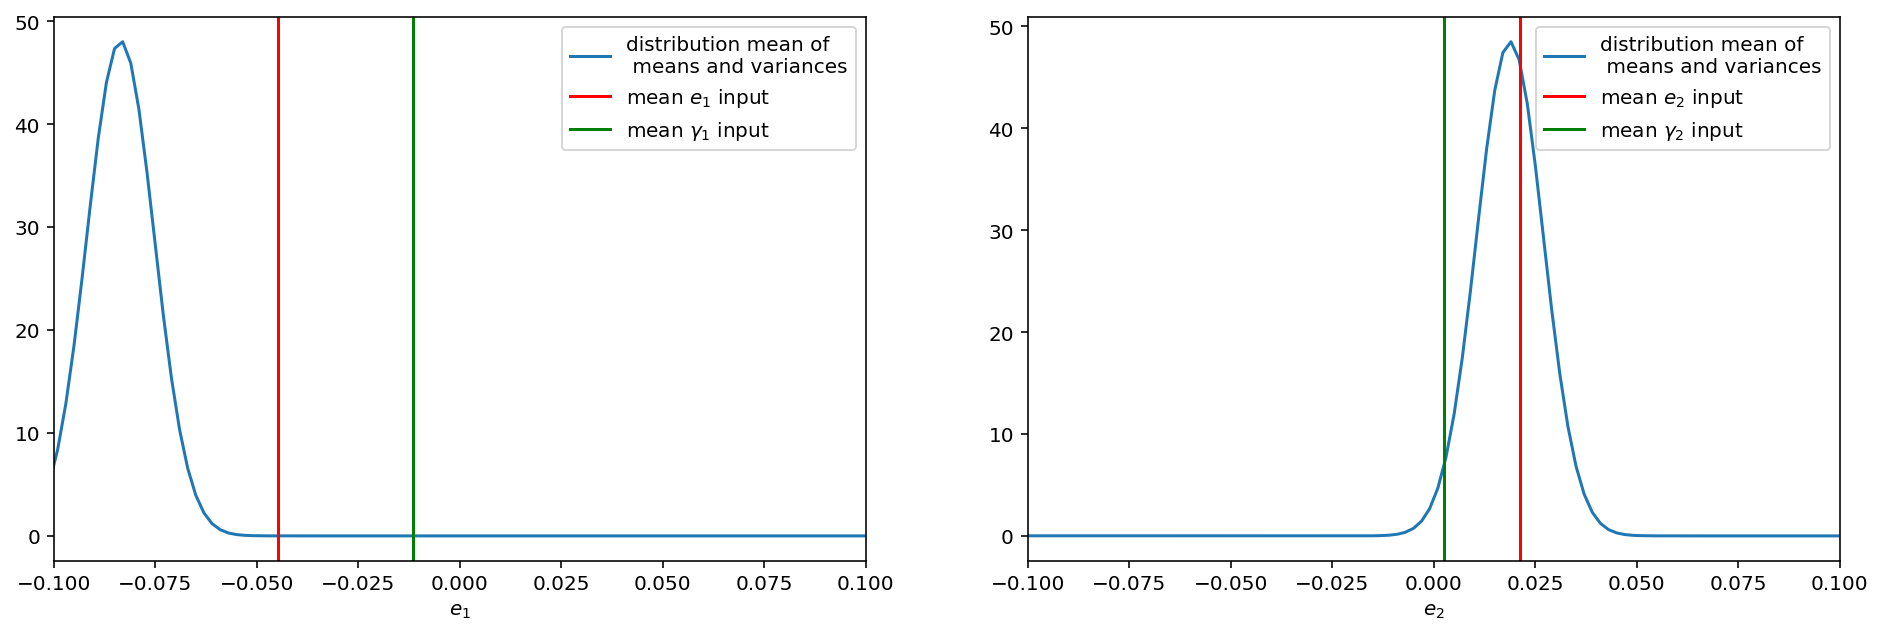

In [112]:
x = np.linspace(-1,1, 1000)

fig, ax = plt.subplots(1,2, figsize = (16,5))
ax[0].plot(x,gaussian(np.mean(e1_out_mean), np.mean(e1_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[0].set_xlim(-0.1, 0.1)
ax[0].axvline(np.mean(-e1[:10]-0.01), color = 'red', label ="mean $e_1$ input")
ax[0].axvline(np.mean(-np.array(data['shear_1'])[:10]-0.01), color = 'green', label = "mean $\gamma_1$ input")
ax[0].set_xlabel('$e_1$')

ax[1].plot(x,gaussian(np.mean(e2_out_mean), np.mean(e2_out_std_bnn)), label ='distribution mean of \n means and variances')
ax[1].set_xlim(-0.1, 0.1)
ax[1].axvline(np.mean(e2[:10]), color = 'red', label ="mean $e_2$ input")
ax[1].axvline(np.mean(-np.array(data['shear_2'])[:10]), color = 'green', label = "mean $\gamma_2$ input")
ax[1].set_xlabel('$e_2$')

ax[0].legend()
ax[1].legend()
print(np.mean(e1_out_mean_bnn), -np.mean(e1[:10]), np.mean(e2_out_mean_bnn), np.mean(e2[:10]))

## Compute shear bias on all sample

In [10]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
image_sheared = np.load(root_dir_v1+'sheared_images.npy', mmap_mode = 'c')

### Case (0,0)

#### Model no PSF

In [11]:
output_v1 = model_no_psf([tf.cast(images, tf.float32), tf.cast(psf, tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [15]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1
df['e2_input'] = e2

df.to_csv('data/res_no_psf_0_0.csv')

In [37]:
df = pd.read_csv('data/res_no_psf_0_0.csv')

In [17]:
import statsmodels.api as sm

df_bias_0_0 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']

    x = sm.add_constant(x, prepend=False)

    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_0_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_0_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_0_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_0_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_0_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_0_0['mean_e'] = np.mean([df_bias_0_0['slope_e1'],df_bias_0_0['slope_e2']], axis = 0)

df_bias_0_0


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.031437,0.002414,0.000532,0.000133,0.004786,0.030378,0.000572,0.000492,0.000121,-0.004908,0.030908


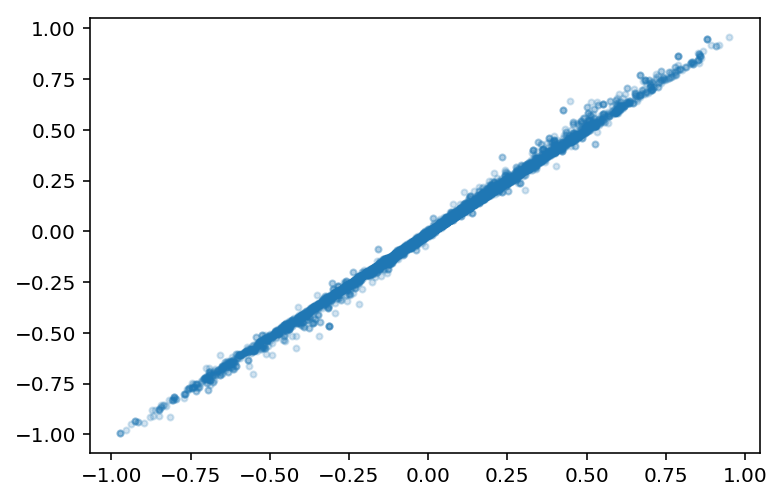

In [38]:
plt.plot(df['e1_input']+0.01,df['e1_res_mean'], '.', alpha = 0.2)

### Case (0.01,0)

#### Model no PSF

In [10]:
output_v1 = model_no_psf([tf.cast(image_sheared[0], tf.float32), tf.cast(psf, tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [11]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1
df['e2_input'] = e2

df.to_csv('data/res_no_psf_p001_0.csv')

In [12]:
df = pd.read_csv('data/res_no_psf_p001_0.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
Unnamed: 0     10000 non-null int64
e1_res_mean    10000 non-null float64
e2_res_mean    10000 non-null float64
e1_res_std     10000 non-null float64
e2_res_std     10000 non-null float64
e1_input       10000 non-null float64
e2_input       10000 non-null float64
dtypes: float64(6), int64(1)
memory usage: 547.0 KB


In [16]:
import statsmodels.api as sm

df_bias_p001_0 = pd.DataFrame()


for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']-0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))#df_test['e'+str(k+1)+'_out'][mask]
    
    df_bias_p001_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_p001_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_p001_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_p001_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_p001_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_p001_0['mean_e'] = np.mean([df_bias_p001_0['slope_e1'],df_bias_p001_0['slope_e2']], axis = 0)
df_bias_p001_0

,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.010669,-0.00676,0.000402,0.000101,-0.014542,0.011958,0.010561,0.000348,0.000086,-0.004941,0.011314


### Model deterministic with PSF

In [11]:
output_v1 = model_concat_one([tf.cast(image_sheared[0][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [12]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_p001_0.csv')

In [41]:
df = pd.read_csv('data/res_det_psf_p001_0.csv')

In [42]:
import statsmodels.api as sm

df_bias_p001_0 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']-0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))#df_test['e'+str(k+1)+'_out'][mask]
    
    df_bias_p001_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_p001_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_p001_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_p001_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_p001_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_p001_0['mean_e'] = np.mean([df_bias_p001_0['slope_e1'],df_bias_p001_0['slope_e2']], axis = 0)
df_bias_p001_0


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.012937,-0.013274,0.000827,0.000205,-0.026074,0.015567,0.007061,0.000686,0.000168,-0.008273,0.014252


In [15]:
import scipy.stats as stats

In [16]:
stats.linregress(df['e1_input']-0.01, df['e1_res_mean'])

LinregressResult(slope=1.012936826802953, intercept=-0.013274233096168606, rvalue=0.9983381249706647, pvalue=0.0, stderr=0.0008270661504149524)

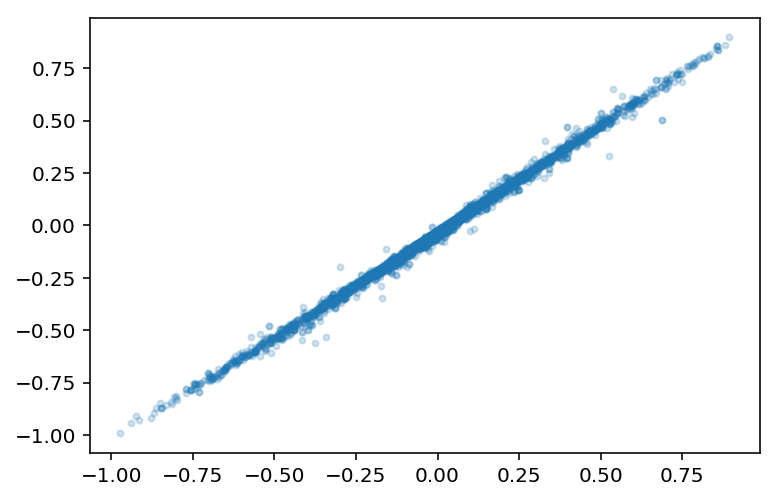

In [17]:
plt.plot(df['e1_input']+0.01,df['e1_res_mean'], '.', alpha = 0.2)

## Case (-0.01,0)

### Model deterministic with PSF

In [10]:
output_v1 = model_concat_one([tf.cast(image_sheared[1][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [11]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_m001_0.csv')

In [34]:
df = pd.read_csv('data/res_det_psf_m001_0.csv')

In [39]:
import statsmodels.api as sm

df_bias_m001_0 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']+0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_m001_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_m001_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_m001_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_m001_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_m001_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_m001_0['mean_e'] = np.mean([df_bias_m001_0['slope_e1'],df_bias_m001_0['slope_e2']], axis = 0)
df_bias_m001_0


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.014305,0.004564,0.00077,0.000191,0.012033,0.015127,-0.013232,0.000694,0.000169,-0.008257,0.014716


In [36]:
df_bias_p001_0['mean_e1'][0], df_bias_m001_0['mean_e1'][0]

(-0.026073742765488704, 0.012033178655844001)

In [37]:
(-df_bias_p001_0['mean_e1'][0]+df_bias_m001_0['mean_e1'][0])/0.02

1.9053460710666352

In [38]:
m_e1 = ((-df_bias_p001_0['mean_e1'][0]+df_bias_m001_0['mean_e1'][0])/0.02)-1
m_e2 = ((df_bias_p001_0['mean_e2'][0]-df_bias_m001_0['mean_e2'][0])/0.02)

print(m_e1,m_e2)

0.9053460710666352 -0.0008153504451499129


## Case (0,0.01)

### Model deterministic with PSF

In [12]:
output_v1 = model_concat_one([tf.cast(image_sheared[2][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [13]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_0_p001.csv')

In [15]:
df = pd.read_csv('data/res_det_psf_0_p001.csv')

In [16]:
import statsmodels.api as sm

df_bias_0_p001 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']+0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_0_p001['slope_e'+str(k+1)] = np.array(slope)
    df_bias_0_p001['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_0_p001['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_0_p001['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_0_p001['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_0_p001['mean_e'] = np.mean([df_bias_0_p001['slope_e1'],df_bias_0_p001['slope_e2']], axis = 0)
df_bias_0_p001


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.014107,-0.014535,0.000786,0.000195,-0.007068,0.015327,0.005824,0.000707,0.000172,0.0108,0.014717


## Case (0,-0.01)

In [11]:
output_v1 = model_concat_one([tf.cast(image_sheared[3][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [12]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_0_m001.csv')

In [13]:
df = pd.read_csv('data/res_det_psf_0_m001.csv')

In [14]:
import statsmodels.api as sm

df_bias_0_m001 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']+0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_0_m001['slope_e'+str(k+1)] = np.array(slope)
    df_bias_0_m001['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_0_m001['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_0_m001['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_0_m001['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_0_m001['mean_e'] = np.mean([df_bias_0_m001['slope_e1'],df_bias_0_m001['slope_e2']], axis = 0)
df_bias_0_m001


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/numpy/core/fromnumeric.py:2580: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.01341,-0.014441,0.000788,0.000196,-0.006978,0.015098,-0.032333,0.000697,0.00017,-0.027358,0.014254


In [19]:
(-0.006978+0.007068), (-0.006978+0.007068)/0.02

(8.99999999999998e-05, 0.00449999999999999)

In [17]:
m_e1 = ((-df_bias_0_p001['mean_e1'][0]+df_bias_0_m001['mean_e1'][0])/0.02)
m_e2 = ((df_bias_0_p001['mean_e2'][0]-df_bias_0_m001['mean_e2'][0])/0.02)-1

print(m_e1,m_e2)

0.004486222165877001 0.9078962894622502


In [22]:
model_concat_one.layers[-1]

## Shear bias estimation

In [201]:
def boxplot_func_shear_bias(df_in, x,ell, y, z,shear,
            xlim, ylim, ylim2, 
            x_scale, 
            legend,
            x_label, y_label, y_label_hist, y_label_2,
            errors = None,
            legend_remove = False,
            palette = ["#3498db","#e74c3c"],
            nbins = 11):
    
    m = []
    c = []
    err = []
    
    import matplotlib as mpl
    mpl.rcdefaults()
    
    if errors is not None:
        df_plot = df_in.drop(errors)
    else:
        df_plot = df_in

    df_plot = df_plot.dropna()
    print(len(df_plot))
    if x_scale == 'log':
        x_bins = np.geomspace(xlim[0], xlim[1], nbins+1)
    else :
        x_bins = np.linspace(xlim[0], xlim[1], nbins+1)
    
    x_bins[0] -= 1e-5
    x_bins[-1] += 1e-5
    
    idx = np.digitize(df_plot[x], x_bins)
    
    fig, axes = plt.subplots(3,1, figsize=(5,4), gridspec_kw={'height_ratios': [1, 3,2]})
    
    if x_scale == 'log':
        sns.distplot(np.log10(df_plot[x]), ax=axes[0], color='0.8')
        axes[0].set_xlim(np.log10(xlim[0]), np.log10(xlim[1]))
    else:
        sns.distplot(df_plot[x], ax=axes[0], color='0.8')
        axes[0].set_xlim(xlim[0], xlim[1])
    
    axes[0].set_yticks([])
    axes[0].set_ylabel(y_label_hist)
    axes[0].set_xticks([])
#####
    print(idx, len(idx))
    exp = np.unique(df_plot[z])
    N_exp = len(exp)
    handles = []
    for ik, key in enumerate(exp):
        stats = {}
        for i in range(1,len(x_bins)):
            xx = df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values+df_plot[shear][np.logical_and(idx==i,df_plot[z]==key)].values
            yy = df_plot[y][np.logical_and(idx==i,df_plot[z]==key)].values
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(xx,yy)

            m.append(slope-1)
            c.append(intercept)
            err.append(std_err)
        handles = exp
        #plt.setp(key, color=palette[ik])
#####        
    
    ax = axes[1]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(m).reshape(N_exp,int(len(m)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    #ax.set_xlim(xlim[0], xlim[1])
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim)
    ax.set_ylabel(y_label)
    ax.xaxis.tick_bottom()
    if not legend_remove:
        ax.legend(handles, legend, frameon=False, loc ='upper right', borderpad = 0.1, fontsize = 10)
           
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    
    ax = axes[2]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(c).reshape(N_exp,int(len(c)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim2)
    ax.set_ylabel(y_label_2)
    ax.xaxis.tick_bottom()
            
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    return fig , m,c,err

Shear bias: $i = 1,2$


$〈\epsilon_{i,obs}〉=g_{i,obs}=c_i+(1+m_i)g_i$


$g_{i,obs}=c_i+(1+m_i)(〈\epsilon_{i,int}〉+g_i)$

source (https://hal-cea.archives-ouvertes.fr/cea-02949701/document)

or $1+m_i=〈R_{ii}〉$ 

with $ R_{αβ} ≈ \frac{e_{obs,+α}−e_{obs,−α}}{2∆g_β}$ , source (https://www.aanda.org/articles/aa/pdf/2019/01/aa33740-18.pdf)

In [140]:
df_v1 = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

In [141]:
df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


In [147]:
df_v2 = df_v1[(np.abs(df_v1['e1'])<=0.1)]

df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6841 entries, 1 to 9999
Data columns (total 14 columns):
id                6841 non-null int64
e1                6841 non-null float64
e2                6841 non-null float64
shear_1           6841 non-null float64
shear_2           6841 non-null float64
redshift          6841 non-null float64
redshift_true     6841 non-null float64
blendedness       6840 non-null float64
snr_r             6839 non-null float64
convergence       6841 non-null float64
e1_hsm_regauss    6827 non-null float64
e2_hsm_regauss    6827 non-null float64
mag_r_meas        6839 non-null float64
mag_r_true        6841 non-null float64
dtypes: float64(13), int64(1)
memory usage: 801.7 KB


In [148]:
df_v2.index

Int64Index([   1,    4,    5,    6,    8,   11,   12,   13,   14,   15,
            ...
            9987, 9989, 9990, 9991, 9992, 9993, 9995, 9997, 9998, 9999],
           dtype='int64', length=6841)

In [152]:
df_v1['e1'][2]

-0.2746974329727165

In [156]:
df_v1['e1'][1]

0.03013658390191807

In [155]:
df_v2['e1'][1]

0.03013658390191807

In [157]:
df_v2['e1'][4], df_v1['e1'][4]

(-0.005709342233080301, -0.005709342233080301)

In [158]:
df_v2['e1'][2]

KeyError: 2

In [241]:
df_plot_hsm = pd.DataFrame()

df_v1 = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')


e_hsm = np.sqrt(-data['e1_hsm_regauss'][:nb_of_points]**2 + data['e2_hsm_regauss'][:nb_of_points]**2)

e = np.sqrt(e1**2+e2**2)
e_out = np.sqrt(e1_out_mean**2+e2_out_mean**2)

df_plot_hsm = pd.concat([df_v1[:nb_of_points], df_v1[:nb_of_points]], ignore_index=True, sort = True)
df_plot_hsm['e_error']=np.concatenate([e_out - e[:nb_of_points], e_hsm-e[:nb_of_points]])
df_plot_hsm['e']=np.concatenate([e[:nb_of_points],e[:nb_of_points]])

df_plot_hsm['exp'] = [1]*nb_of_points + [2]*nb_of_points

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in sqrt
  


In [139]:
df_plot_hsm['e1_meas']= np.concatenate([e1_out_mean, data['e1_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e2_meas']= np.concatenate([e2_out_mean, data['e2_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e1_sheared'] = np.concatenate([-e1[:nb_of_points],-e1[:nb_of_points]])
df_plot_hsm['e2_sheared'] = np.concatenate([e2[:nb_of_points],e2[:nb_of_points]])

NameError: name 'df_plot_hsm' is not defined

In [243]:
ellipticity = calc_lensed_ellipticity(-df_plot_hsm['e1'].values, df_plot_hsm['e2'].values, 0,0, 0)

In [244]:
df_plot_hsm['e1_conv'] = ellipticity_conversion(df_plot_hsm['e1'])
df_plot_hsm['e2_conv'] = ellipticity_conversion(df_plot_hsm['e2'])

In [245]:
np.min(df_plot_hsm['snr_r'])

39.86887204889025

1527
[6 1 1 ... 7 3 5] 1527


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


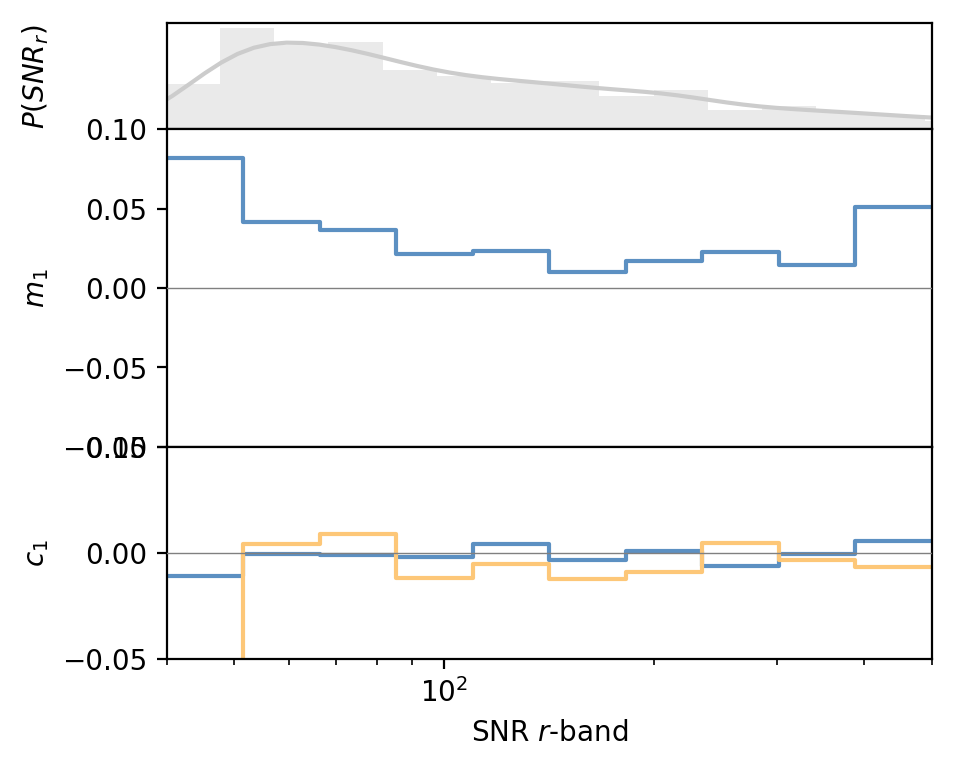

In [247]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (40, 500),
              ylim = (-0.1,0.1), 
              ylim2 = (-0.05, 0.05), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.35]),
              nbins = 10)

1996
[5 0 0 ... 1 2 5] 1996


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


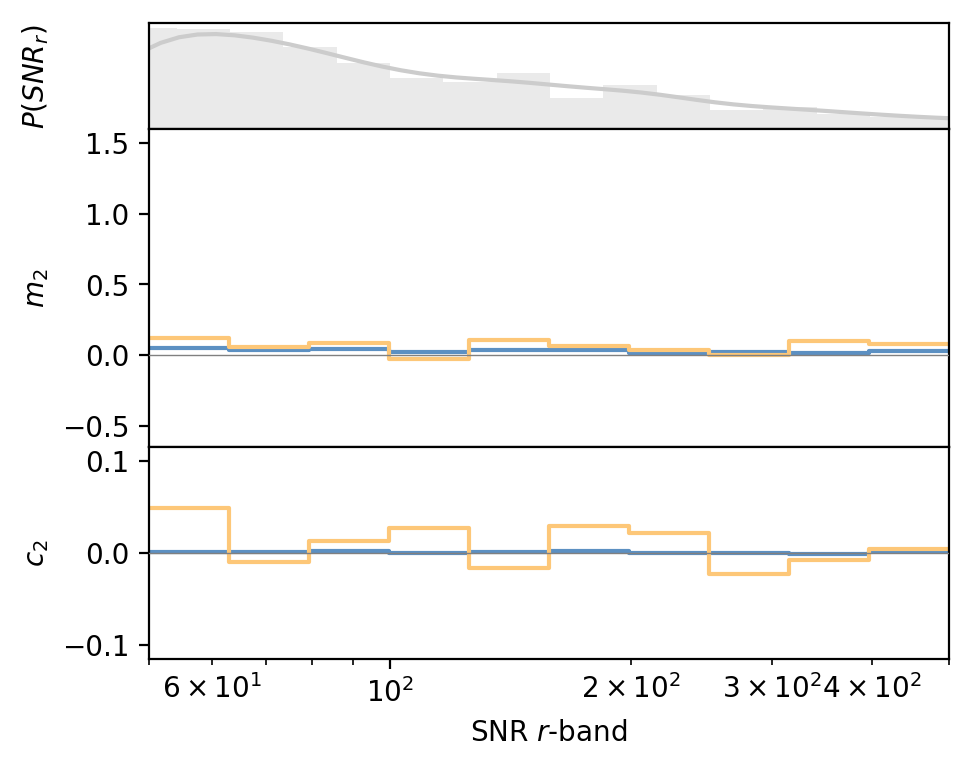

In [214]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e2_conv', y = 'e2_meas', z = 'exp', shear = 'shear_2',
              xlim = (50, 500),
              ylim = (-0.65,1.6), 
              ylim2 = (-0.115, 0.115), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_2$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_2$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,.35]),#0.35,
              nbins = 10)

In [249]:
df_plot_hsm_2 = df_plot_hsm[(df_plot_hsm['blendedness']>0.0000001)]

1157
[3 8 6 ... 9 4 4] 1157


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


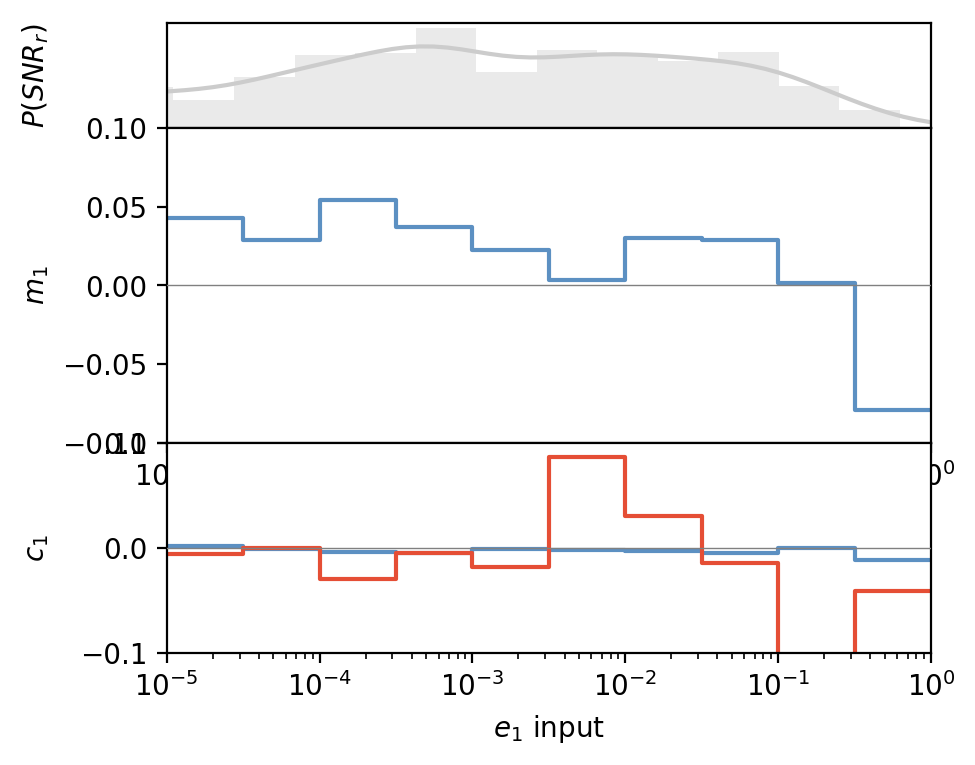

In [252]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm_2, 
              x = 'blendedness', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (0.00001, 1),
              ylim = (-0.1,0.1), 
              ylim2 = (-0.1, 0.1), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

1996
[4 5 9 ... 6 8 6] 1996


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)


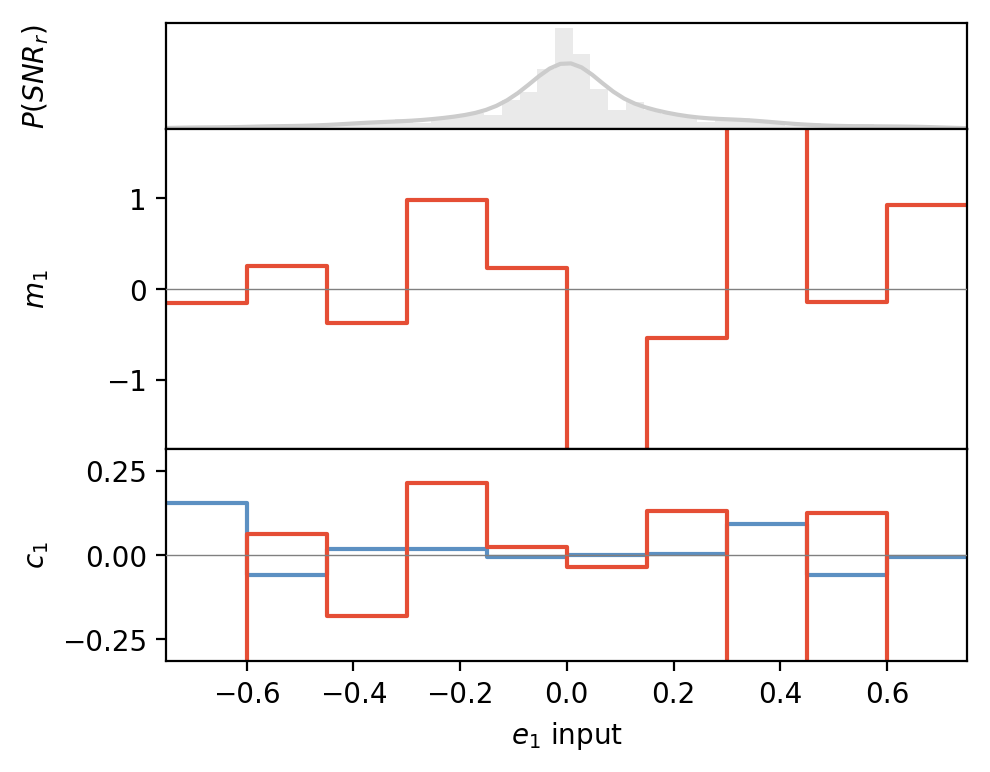

In [215]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'e1_conv', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (-0.75, 0.75),
              ylim = (-1.76,1.76), 
              ylim2 = (-0.315, 0.315), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)